
# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#8b4513;">Deep Learning-Driven Motor Movement Intent Decoding from EEG Motor Imagery Data: An EEGNet-Based Approach for Robust BCI Classification
![EEG Image 2](image2.png)



# EEG Motor Imagery Classification — Left vs Right Hand
### PhysioNet BCI2000 Dataset | FBCSP + 5 Base Models + Logistic Regression Meta-Ensemble

**Pipeline overview:**
1. Load EDF files → ICA artifact removal → Epoching (T1/T2 events)
2. Per-subject good/bad screening via CSP accuracy
3. Pool good subjects → CSP feature extraction
4. Train FBCSP+LDA (§10.1), FBCSP+SVM (§10.2), FBCSP+Random Forest (§10.3),
   FBCSP+Logistic Regression (§10.4), and FBCSP+XGBoost (§10.5) individually
5. LR-Meta Ensemble Learning VS EEGNet vs DeepConvNet
6. Full evaluation: metrics, confusion matrices, subject charts, accuracy/loss curves


## 1. Setup & Imports

In [1]:
!pip install mne scikit-learn numpy matplotlib seaborn pandas joblib tensorflow xgboost



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne import Epochs, pick_types, events_from_annotations
from mne.io import read_raw_edf
from mne.decoding import CSP
from mne.preprocessing import ICA

In [3]:
import mne
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import log_loss
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.signal import butter, filtfilt

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Dataset Path Locator (`BASE_DIR`)

In [4]:
BASE_DIR = r"G:\CSE 4200 Project and Thesis\Implementation\BCI_classification\mi-dataset-1.0.0\files"
if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(f"BASE_DIR not found:\n{BASE_DIR}")

subject_dirs_all = sorted(
    [d for d in os.listdir(BASE_DIR)
     if d.startswith("S") and os.path.isdir(os.path.join(BASE_DIR, d))]
)
print(f"BASE_DIR found. {len(subject_dirs_all)} subject folders detected.")


BASE_DIR found. 109 subject folders detected.


In [5]:
def get_subject_edf_files(subject_id, base_dir=BASE_DIR):
    """Return all .edf file paths for a given subject."""
    return sorted(glob.glob(os.path.join(base_dir, subject_id, f"{subject_id}R*.edf")))

def get_motor_imagery_runs(subject_id, base_dir=BASE_DIR):
    """Return R04, R08, R12 — LEFT vs RIGHT hand imagination runs only."""
    target_runs = ["04", "08", "12"]
    return [f for f in get_subject_edf_files(subject_id, base_dir)
            if any(f"R{r}.edf" in f for r in target_runs)]


## 3. Remove Known Bad Subjects

In [6]:
BAD_SUBJECTS = {
    "S038", "S088", "S089", "S092", "S100", "S104",
    "S003", "S004", "S009", "S012", "S014", "S021",
    "S022", "S027", "S030", "S036", "S039", "S045",
    "S048", "S051"
}
clean_subjects = [s for s in subject_dirs_all if s not in BAD_SUBJECTS]
print(f"Total subjects:          {len(subject_dirs_all)}")
print(f"Bad subjects removed:    {len(BAD_SUBJECTS)}")
print(f"Clean subjects remaining:{len(clean_subjects)}")


Total subjects:          109
Bad subjects removed:    20
Clean subjects remaining:89


## 4. Motor-Cortex Channel Selection

In [7]:
MOTOR_CHANNELS = ["C3", "C4", "CZ", "FC3", "FC4", "CP3", "CP4",
                   "P3", "P4", "F3", "F4", "FCZ", "CPZ"]
print(f"Using {len(MOTOR_CHANNELS)} motor channels: {MOTOR_CHANNELS}")


Using 13 motor channels: ['C3', 'C4', 'CZ', 'FC3', 'FC4', 'CP3', 'CP4', 'P3', 'P4', 'F3', 'F4', 'FCZ', 'CPZ']


## 5. Configuration

In [8]:
PILOT_MODE            = True
N_PILOT_SUBJECTS      = 89
RUNS                  = ["04", "08", "12"]   # R04Motor Imagery - Left/Right Hand(S001R04.edf)
TMIN, TMAX            = 0.5, 4.0      # active imagery window (widened 3.5s -> 4.0s:
                                       # more samples/trial -> more stable CSP covariance)
FILTER_LOW            = 8.0           # mu band start Mu rhythm (8–12 Hz) and Beta rhythm
FILTER_HIGH           = 30.0          # beta band end
EPOCH_REJECT_THRESHOLD= 100e-6        # ±100 µV artifact rejection (per your spec)
GOOD_SUBJECT_THRESHOLD = 0.75

subjects_to_use = clean_subjects[:N_PILOT_SUBJECTS] if PILOT_MODE else clean_subjects
print(f"{'PILOT' if PILOT_MODE else 'FULL'} MODE: {len(subjects_to_use)} subjects")


PILOT MODE: 89 subjects


## 6. Preprocessing — ICA Artifact Removal + Epoching

**Why this pipeline is ordered this way:**

| Step | What | Why |
|------|------|-----|
| 1 | Load & rename channels | Standardise names across subjects |
| 2 | Pick motor channels | Reduces ICA dimensions, focuses on signal |
| 3 | Band-pass 8–30 Hz | Remove DC drift, high-freq muscle noise; keep mu+beta |
| 4 | Average reference | Remove common-mode noise |
| 5 | **ICA on continuous data** | Best practice: run ICA *before* epoching on continuous filtered signal so component waveforms are undistorted |
| 6 | Identify & remove eye-blink / muscle components | Frontal components = EOG; high-freq noisy = EMG |
| 7 | **Epoch on T1/T2 events** | Cut continuous clean signal into event-locked trials (-0.5 s → +4 s, baseline -0.5→0 s) |
| 8 | Reject bad epochs (±100 µV) | Remove residual artifacts missed by ICA |
| 9 | Crop to active window (0.5–3.5 s) | Remove stimulus-onset transient; keep stable imagery |


In [ ]:
def load_subject_epochs(subject_id, base_dir=BASE_DIR, runs=RUNS,
                         l_freq=FILTER_LOW, h_freq=FILTER_HIGH,
                         tmin=TMIN, tmax=TMAX,
                         channels=MOTOR_CHANNELS):

    files = get_motor_imagery_runs(subject_id, base_dir)
    if not files:
        return None

    # ── Step 1: Load all imagery runs and concatenate ──────────────────
    raws = []
    for f in files:
        try:
            raw = read_raw_edf(f, preload=True, verbose=False)
            raw.rename_channels(lambda ch: ch.strip(".").upper())
            raws.append(raw)
        except Exception as e:
            print(f"  [WARN] {subject_id}: {e}")
    if not raws:
        return None
    raw = mne.concatenate_raws(raws)

    # ── Step 2: Pick motor channels ────────────────────────────────────
    missing = [ch for ch in channels if ch not in raw.ch_names]
    if missing:
        print(f"  [SKIP] {subject_id}: missing channels {missing}")
        return None
    raw.pick(channels)

    # ── Step 3 & 4: Band-pass filter + average reference ───────────────
    raw.filter(l_freq, h_freq, fir_design="firwin",
               skip_by_annotation="edge", verbose=False)
    raw.set_eeg_reference("average", projection=False, verbose=False)

    # ── Step 5 & 6: ICA — run on continuous signal, remove artifacts ───
    # n_components = channels-1 so ICA is full-rank after avg reference
    n_ica = min(len(channels) - 1, 12)
    ica = ICA(n_components=n_ica, method="fastica",
              random_state=RANDOM_STATE, max_iter=800)
    ica.fit(raw, verbose=False)

    # Auto-detect EOG (eye-blink) components using the most frontal channel
    frontal_proxy = [ch for ch in ["F3", "F4", "FCZ", "CZ"] if ch in raw.ch_names]
    eog_idx = []
    if frontal_proxy:
        eog_idx, _ = ica.find_bads_eog(raw, ch_name=frontal_proxy[0],
                                        threshold=2.5, verbose=False)

    # Auto-detect muscle components
    muscle_idx, _ = ica.find_bads_muscle(raw, verbose=False)

    # Only remove components flagged by either detector (union), capped at n_ica/3
    remove_idx = list(set(eog_idx) | set(muscle_idx))
    remove_idx = remove_idx[: max(1, n_ica // 3)]   # never remove more than 1/3 of components
    ica.exclude = remove_idx
    raw = ica.apply(raw, verbose=False)

    # ── Step 7: Extract events and epoch ───────────────────────────────
    events, event_id = events_from_annotations(raw, verbose=False)
    wanted = {k: v for k, v in event_id.items() if k in ("T1", "T2")}
    if len(wanted) < 2:
        return None

    picks = pick_types(raw.info, eeg=True, exclude="bads")

    # Epoch with full window first; baseline correction -0.5→0 s (per your spec)
    epochs = Epochs(
        raw, events, event_id=wanted,
        tmin=-0.5, tmax=4.0,
        picks=picks,
        baseline=(-0.5, 0),          # ← baseline correction as specified
        preload=True, verbose=False,
        reject=dict(eeg=EPOCH_REJECT_THRESHOLD),   # ±100 µV (per your spec)
    )
    if len(epochs) == 0:
        return None

    # ── Step 8: Crop to active imagery window (removes baseline period) ─
    epochs.crop(tmin=tmin, tmax=tmax)
    return epochs


def standardize_epochs_per_subject(X):
    """Per-subject z-score: removes amplitude-scale differences between subjects."""
    mu  = X.mean(axis=(0, 2), keepdims=True)
    sig = X.std(axis=(0, 2),  keepdims=True) + 1e-12
    return (X - mu) / sig  # z-score normalization across trials and channels for each subject


# ── Quick sanity check on one subject ──────────────────────────────────────
test_ep = load_subject_epochs(subjects_to_use[0])
if test_ep is not None:
    print(test_ep)
    print("Channels:", test_ep.ch_names)
    print("Events:", {k: len(test_ep[k]) for k in test_ep.event_id})
else:
    print("No valid epochs for test subject.")


<Epochs | 30 events (all good), 0.5 – 4 s (baseline -0.5 – 0 s (baseline period was cropped after baseline correction)), ~1.7 MiB, data loaded,
 np.str_('T1'): 13
 np.str_('T2'): 17>
Channels: ['C3', 'C4', 'CZ', 'FC3', 'FC4', 'CP3', 'CP4', 'P3', 'P4', 'F3', 'F4', 'FCZ', 'CPZ']
Events: {np.str_('T1'): 13, np.str_('T2'): 17}


## 7. Load All Subjects

In [10]:
subject_xy = {}
for subj in subjects_to_use:
    ep = load_subject_epochs(subj)
    if ep is None or len(ep) < 20:
        continue
    X = ep.get_data(copy=True)
    label_map = {ep.event_id["T1"]: 0, ep.event_id["T2"]: 1}
    y = np.array([label_map[e] for e in ep.events[:, -1]])
    if len(np.unique(y)) < 2 or min(np.bincount(y)) < 4:
        continue
    X = standardize_epochs_per_subject(X)
    subject_xy[subj] = (X, y)

print(f"Loaded {len(subject_xy)}/{len(subjects_to_use)} subjects successfully.")


Loaded 56/89 subjects successfully.


## 8. Per-Subject Screening → Good / Bad Subject Split

In [11]:
def per_subject_csp_accuracy(X, y, n_components=6, test_size=0.3):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y)
    csp_ = CSP(n_components=n_components, reg="ledoit_wolf", log=True, norm_trace=False)
    Xtr_c = csp_.fit_transform(Xtr, ytr)
    Xte_c = csp_.transform(Xte)
    acc_lda = accuracy_score(yte, LDA().fit(Xtr_c, ytr).predict(Xte_c))
    svm_ = Pipeline([("sc", StandardScaler()),
                     ("sv", SVC(kernel="rbf", C=1.0, gamma="scale",
                                random_state=RANDOM_STATE))])
    svm_.fit(Xtr_c, ytr)
    acc_svm = accuracy_score(yte, svm_.predict(Xte_c))
    return acc_lda, acc_svm

screening_results = []
for subj, (X, y) in subject_xy.items():
    try:
        al, av = per_subject_csp_accuracy(X, y)
    except Exception:
        al, av = np.nan, np.nan
    screening_results.append({
        "subject": subj, "n_trials": len(y),
        "CSP_LDA_acc": al, "CSP_SVM_acc": av,
        "best_acc": np.nanmax([al, av]),
    })

screening_df = (pd.DataFrame(screening_results)
                  .sort_values("best_acc", ascending=False)
                  .reset_index(drop=True))
print(f"Screened {len(screening_df)} subjects.")
screening_df.head(10)


Screened 56 subjects.


,subject,n_trials,CSP_LDA_acc,CSP_SVM_acc,best_acc
0,S001,30,1.000000,0.777778,1.000000
1,S007,41,1.000000,1.000000,1.000000
2,S034,43,1.000000,1.000000,1.000000
3,S029,40,1.000000,0.916667,1.000000
4,S085,37,0.916667,1.000000,1.000000
5,S062,43,1.000000,0.923077,1.000000
6,S026,45,0.857143,0.928571,0.928571
7,S042,45,0.857143,0.928571,0.928571
8,S072,43,0.923077,0.923077,0.923077
9,S071,37,0.916667,0.916667,0.916667


In [12]:
good_subjects = screening_df.loc[
    screening_df["best_acc"] > GOOD_SUBJECT_THRESHOLD, "subject"].tolist()
bad_subjects_screened = screening_df.loc[
    screening_df["best_acc"] < GOOD_SUBJECT_THRESHOLD, "subject"].tolist()

print(f"Good subjects (> {GOOD_SUBJECT_THRESHOLD*100:.0f}%): {len(good_subjects)}")
print(f"Bad  subjects (< {GOOD_SUBJECT_THRESHOLD*100:.0f}%): {len(bad_subjects_screened)}")
if len(good_subjects) < 10:
    print("[WARNING] Very few good subjects — lower GOOD_SUBJECT_THRESHOLD if needed.")
    


Good subjects (> 75%): 22
Bad  subjects (< 75%): 31


## 9. Pool Good-Subject Trials

In [13]:
X_good    = np.concatenate([subject_xy[s][0] for s in good_subjects])
y_good    = np.concatenate([subject_xy[s][1] for s in good_subjects])
groups_good = np.concatenate([[s]*len(subject_xy[s][1]) for s in good_subjects])

print("Pooled shape:", X_good.shape)
print(f"Class balance — Left: {np.sum(y_good==0)}   Right: {np.sum(y_good==1)}")


Pooled shape: (883, 13, 561)
Class balance — Left: 442   Right: 441


## 10. Train / Test Split + CSP Feature Extraction

> **Why CSP?**
> Common Spatial Patterns (CSP) is the gold-standard spatial filter for EEG motor imagery.
> It finds a set of linear combinations of EEG channels that **maximise variance for one class
> (e.g. Left hand) while simultaneously minimising variance for the other (Right hand)**.
> This directly exploits Event-Related De-synchronisation (ERD) — the suppression of mu/beta
> power over the contralateral motor cortex during imagined movement — which is the core
> neurological signal separating Left and Right hand imagination.
>
> **Where:** CSP is fit **only on the training set** (to prevent leakage), then applied as a
> feature transformer to train, test, and every LOSO fold.
>
> **Output:** log-variance of each CSP-filtered signal → a compact feature vector fed to
> LDA and SVM classifiers.


> **Update:** each base model below now uses a **Filter-Bank CSP (FBCSP)** front end instead of single broadband CSP. Motor-imagery ERD/ERS does not spread evenly across 8-30 Hz — splitting into narrow sub-bands and fitting CSP per band lets each classifier see *which* rhythm carried the discriminative signal for a given trial, instead of one blended broadband estimate. This is the standard Ang et al. (2008) FBCSP approach and is the single biggest lever available here without changing the classifiers themselves.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_good, y_good, test_size=0.30, random_state=RANDOM_STATE, stratify=y_good)
print(f"Train: {X_train.shape[0]}   Test: {X_test.shape[0]}")

print("\nEach base model below tunes its OWN CSP component count jointly with its own")
print("classifier hyperparameters via GridSearchCV / RandomizedSearchCV on the training")
print("set. Previously every model used a fixed, untuned CSP rank (6, 4, 6, 8, 4) and")
print("fixed classifier hyperparameters guessed up front — this is the main lever for")
print("pushing each base model's accuracy up.")


Train: 618   Test: 265

Each base model below tunes its OWN CSP component count jointly with its own
classifier hyperparameters via GridSearchCV / RandomizedSearchCV on the training
set. Previously every model used a fixed, untuned CSP rank (6, 4, 6, 8, 4) and
fixed classifier hyperparameters guessed up front — this is the main lever for
pushing each base model's accuracy up.


In [15]:
# ── Filter-Bank CSP (FBCSP) front end ──────────────────────────────────────
# Ang et al. (2008): fit a separate CSP per narrow sub-band, concatenate the
# log-variance features, then keep only the most informative ones (mutual
# information). This replaces the single broadband 8-30 Hz CSP used previously
# and is the main preprocessing/feature upgrade behind the accuracy gains below.
#
# The band-pass filtering itself does not depend on class labels, so it is safe
# to precompute ONCE per split (X_train / X_test) rather than re-filtering inside
# every GridSearchCV fold — this also makes the hyperparameter search far faster.

FBCSP_BANDS = [(8, 12), (10, 14), (12, 16), (14, 18), (16, 20),
               (18, 22), (20, 24), (22, 26), (24, 30)]
SFREQ = 160.0  # PhysioNet EEGMMIDB sampling rate


def build_filterbank(X, bands=FBCSP_BANDS, sfreq=SFREQ, order=4):
    """(n_trials, n_channels, n_samples) -> (n_trials, n_bands, n_channels, n_samples)"""
    nyq = sfreq / 2.0
    out = np.empty((X.shape[0], len(bands), X.shape[1], X.shape[2]), dtype=np.float64)
    for bi, (low, high) in enumerate(bands):
        b, a = butter(order, [low / nyq, high / nyq], btype="band")
        out[:, bi] = filtfilt(b, a, X, axis=-1)
    return out


class FilterBankCSP(BaseEstimator, TransformerMixin):
    """Per-band CSP log-variance features + mutual-information feature selection.

    Input to fit/transform is the pre-filtered 4-D array from build_filterbank
    (n_trials, n_bands, n_channels, n_samples), so this step itself does no
    filtering — it only fits CSP per band and selects the best features.
    """
    def __init__(self, n_components=4, reg="ledoit_wolf", k_best=16):
        self.n_components = n_components
        self.reg = reg
        self.k_best = k_best

    def fit(self, Xfb, y):
        self.csps_ = []
        feats = []
        for bi in range(Xfb.shape[1]):
            csp = CSP(n_components=self.n_components, reg=self.reg,
                      log=True, norm_trace=False)
            feats.append(csp.fit_transform(Xfb[:, bi], y))
            self.csps_.append(csp)
        feats = np.concatenate(feats, axis=1)
        k = min(self.k_best, feats.shape[1])
        self.selector_ = SelectKBest(mutual_info_classif, k=k)
        self.selector_.fit(feats, y)
        return self

    def transform(self, Xfb):
        feats = [csp.transform(Xfb[:, bi]) for bi, csp in enumerate(self.csps_)]
        feats = np.concatenate(feats, axis=1)
        return self.selector_.transform(feats)


# ── Precompute filter-bank data once for the held-out train/test split ─────
X_train_fb = build_filterbank(X_train)
X_test_fb  = build_filterbank(X_test)
print(f"Filter bank: {len(FBCSP_BANDS)} sub-bands  ->  "
      f"X_train_fb {X_train_fb.shape}   X_test_fb {X_test_fb.shape}")


Filter bank: 9 sub-bands  ->  X_train_fb (618, 9, 13, 561)   X_test_fb (265, 9, 13, 561)


## 10.1 CSP + LDA Classifier 

In [16]:
# ── Tune FBCSP rank/k_best + LDA solver/shrinkage jointly via GridSearchCV ──
lda_pipe = Pipeline([
    ("fbcsp", FilterBankCSP(reg="ledoit_wolf")),
    ("clf", LDA()),
])
lda_param_grid = {
    "fbcsp__n_components": [2, 3, 4],
    "fbcsp__k_best":       [10, 16, 20, 24],
    "clf__solver":    ["lsqr", "eigen"],
    "clf__shrinkage":  ["auto", 0.1, 0.3, 0.5],
}
lda_grid = GridSearchCV(
    lda_pipe, lda_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", n_jobs=-1,
)
lda_grid.fit(X_train_fb, y_train)
lda_model = lda_grid.best_estimator_
fbcsp_lda = lda_model.named_steps["fbcsp"]

print(f"Best FBCSP+LDA params: {lda_grid.best_params_}")
print(f"FBCSP+LDA CV best score: {lda_grid.best_score_*100:.2f}%")

y_pred_lda = lda_model.predict(X_test_fb)
acc_lda    = accuracy_score(y_test, y_pred_lda)

prec_lda, rec_lda, f1_lda, sup_lda = precision_recall_fscore_support(
    y_test, y_pred_lda, labels=[0, 1])

print(f"\nFBCSP + LDA  Test Accuracy: {acc_lda*100:.2f}%")
print("\nPer-class metrics (Left=0, Right=1):")
for i, name in enumerate(["Left", "Right"]):
    print(f"  {name}: precision={prec_lda[i]:.4f}  recall={rec_lda[i]:.4f}"
          f"  f1={f1_lda[i]:.4f}  support={sup_lda[i]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lda,
                             target_names=["Left","Right"], digits=4))


Best FBCSP+LDA params: {'clf__shrinkage': 0.1, 'clf__solver': 'lsqr', 'fbcsp__k_best': 16, 'fbcsp__n_components': 4}
FBCSP+LDA CV best score: 79.77%

FBCSP + LDA  Test Accuracy: 80.75%

Per-class metrics (Left=0, Right=1):
  Left: precision=0.8203  recall=0.7895  f1=0.8046  support=133
  Right: precision=0.7956  recall=0.8258  f1=0.8104  support=132

Classification Report:
              precision    recall  f1-score   support

        Left     0.8203    0.7895    0.8046       133
       Right     0.7956    0.8258    0.8104       132

    accuracy                         0.8075       265
   macro avg     0.8080    0.8076    0.8075       265
weighted avg     0.8080    0.8075    0.8075       265



### CSP Spatial Patterns

In [17]:
try:
    info_tmpl = mne.create_info(MOTOR_CHANNELS, sfreq=SFREQ, ch_types="eeg")
    info_tmpl.set_montage(mne.channels.make_standard_montage("standard_1005"),
                          on_missing="ignore")
    # FBCSP fits one CSP per sub-band; plot the lowest sub-band (8-12 Hz, mu
    # rhythm) as a representative example of the spatial patterns learned.
    example_band_idx = 0
    example_csp = fbcsp_lda.csps_[example_band_idx]
    low, high = FBCSP_BANDS[example_band_idx]
    fig = example_csp.plot_patterns(info_tmpl, ch_type="eeg",
                                units="Patterns (AU)", size=1.5, show=False)
    fig.suptitle(f"CSP Spatial Patterns — FBCSP sub-band {low}-{high} Hz "
                 f"({example_csp.n_components}-component, tuned LDA branch)", y=1.02)
    plt.show()
except Exception as e:
    print(f"Pattern plot skipped: {e}")


Pattern plot skipped: The following electrodes have overlapping positions, which causes problems during visualization:
CZ, FCZ, CPZ


## 10.2 CSP + SVM Classifier 

In [18]:
# ── Tune FBCSP rank/k_best + SVM C/gamma jointly via GridSearchCV ──────────
svm_pipe = Pipeline([
    ("fbcsp",  FilterBankCSP(reg="ledoit_wolf")),
    ("scaler", StandardScaler()),
    ("clf",    SVC(kernel="rbf", probability=True, class_weight="balanced",
                   random_state=RANDOM_STATE)),
])
svm_param_grid = {
    "fbcsp__n_components": [2, 3, 4],
    "fbcsp__k_best":       [10, 16, 20, 24],
    "clf__C":     [1, 10, 50, 100, 200],
    "clf__gamma": ["scale", 0.1, 0.03, 0.01, 0.003],
}
svm_grid = GridSearchCV(
    svm_pipe, svm_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", n_jobs=-1,
)
svm_grid.fit(X_train_fb, y_train)
svm_model = svm_grid.best_estimator_
fbcsp_svm = svm_model.named_steps["fbcsp"]

print(f"Best FBCSP+SVM params: {svm_grid.best_params_}")
print(f"FBCSP+SVM CV best score: {svm_grid.best_score_*100:.2f}%")

y_pred_svm = svm_model.predict(X_test_fb)
acc_svm    = accuracy_score(y_test, y_pred_svm)

prec_svm, rec_svm, f1_svm, sup_svm = precision_recall_fscore_support(
    y_test, y_pred_svm, labels=[0, 1])

print(f"\nFBCSP + SVM  Test Accuracy: {acc_svm*100:.2f}%")
print("\nPer-class metrics (Left=0, Right=1):")
for i, name in enumerate(["Left", "Right"]):
    print(f"  {name}: precision={prec_svm[i]:.4f}  recall={rec_svm[i]:.4f}"
          f"  f1={f1_svm[i]:.4f}  support={sup_svm[i]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm,
                             target_names=["Left","Right"], digits=4))


Best FBCSP+SVM params: {'clf__C': 50, 'clf__gamma': 0.01, 'fbcsp__k_best': 16, 'fbcsp__n_components': 3}
FBCSP+SVM CV best score: 83.00%

FBCSP + SVM  Test Accuracy: 81.13%

Per-class metrics (Left=0, Right=1):
  Left: precision=0.8120  recall=0.8120  f1=0.8120  support=133
  Right: precision=0.8106  recall=0.8106  f1=0.8106  support=132

Classification Report:
              precision    recall  f1-score   support

        Left     0.8120    0.8120    0.8120       133
       Right     0.8106    0.8106    0.8106       132

    accuracy                         0.8113       265
   macro avg     0.8113    0.8113    0.8113       265
weighted avg     0.8113    0.8113    0.8113       265



## 10.3 CSP + Random Forest Classifier 

In [19]:
# ── Tune FBCSP rank/k_best + Random Forest hyperparameters via RandomizedSearchCV
rf_pipe = Pipeline([
    ("fbcsp", FilterBankCSP(reg="ledoit_wolf")),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                    class_weight="balanced_subsample")),
])
rf_param_dist = {
    "fbcsp__n_components":   [2, 3, 4],
    "fbcsp__k_best":         [10, 16, 20, 24, 30],
    "clf__n_estimators":     [200, 300, 400, 600, 800],
    "clf__max_depth":        [4, 6, 8, 10, 14, None],
    "clf__min_samples_leaf": [1, 2, 3, 5],
    "clf__max_features":     ["sqrt", "log2", 0.5],
}
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=60,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train_fb, y_train)
rf_model = rf_search.best_estimator_
fbcsp_rf  = rf_model.named_steps["fbcsp"]

print(f"Best FBCSP+RandomForest params: {rf_search.best_params_}")
print(f"FBCSP+RandomForest CV best score: {rf_search.best_score_*100:.2f}%")

y_pred_rf = rf_model.predict(X_test_fb)
acc_rf    = accuracy_score(y_test, y_pred_rf)

prec_rf, rec_rf, f1_rf, sup_rf = precision_recall_fscore_support(
    y_test, y_pred_rf, labels=[0, 1])

print(f"\nFBCSP + Random Forest  Test Accuracy: {acc_rf*100:.2f}%")
print("\nPer-class metrics (Left=0, Right=1):")
for i, name in enumerate(["Left", "Right"]):
    print(f"  {name}: precision={prec_rf[i]:.4f}  recall={rec_rf[i]:.4f}"
          f"  f1={f1_rf[i]:.4f}  support={sup_rf[i]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                             target_names=["Left","Right"], digits=4))


Best FBCSP+RandomForest params: {'fbcsp__n_components': 4, 'fbcsp__k_best': 10, 'clf__n_estimators': 800, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 10}
FBCSP+RandomForest CV best score: 81.54%

FBCSP + Random Forest  Test Accuracy: 81.51%

Per-class metrics (Left=0, Right=1):
  Left: precision=0.8088  recall=0.8271  f1=0.8178  support=133
  Right: precision=0.8217  recall=0.8030  f1=0.8123  support=132

Classification Report:
              precision    recall  f1-score   support

        Left     0.8088    0.8271    0.8178       133
       Right     0.8217    0.8030    0.8123       132

    accuracy                         0.8151       265
   macro avg     0.8153    0.8150    0.8151       265
weighted avg     0.8152    0.8151    0.8151       265



## 10.4 CSP + Logistic Regression Classifier 

In [20]:
# ── Tune FBCSP rank/k_best + Logistic Regression C jointly via GridSearchCV ──
lr_pipe = Pipeline([
    ("fbcsp",  FilterBankCSP(reg="ledoit_wolf")),
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                   class_weight="balanced")),
])
lr_param_grid = {
    "fbcsp__n_components": [2, 3, 4],
    "fbcsp__k_best":       [10, 16, 20, 24],
    "clf__C":       [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
    "clf__penalty": ["l2"],
    "clf__solver":  ["lbfgs"],
}
lr_grid = GridSearchCV(
    lr_pipe, lr_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", n_jobs=-1,
)
lr_grid.fit(X_train_fb, y_train)
lr_model = lr_grid.best_estimator_
fbcsp_lr  = lr_model.named_steps["fbcsp"]

print(f"Best FBCSP+LogisticRegression params: {lr_grid.best_params_}")
print(f"FBCSP+LogisticRegression CV best score: {lr_grid.best_score_*100:.2f}%")

y_pred_lr = lr_model.predict(X_test_fb)
acc_lr    = accuracy_score(y_test, y_pred_lr)

prec_lr, rec_lr, f1_lr, sup_lr = precision_recall_fscore_support(
    y_test, y_pred_lr, labels=[0, 1])

print(f"\nFBCSP + Logistic Regression  Test Accuracy: {acc_lr*100:.2f}%")
print("\nPer-class metrics (Left=0, Right=1):")
for i, name in enumerate(["Left", "Right"]):
    print(f"  {name}: precision={prec_lr[i]:.4f}  recall={rec_lr[i]:.4f}"
          f"  f1={f1_lr[i]:.4f}  support={sup_lr[i]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
                             target_names=["Left","Right"], digits=4))


Best FBCSP+LogisticRegression params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'fbcsp__k_best': 24, 'fbcsp__n_components': 4}
FBCSP+LogisticRegression CV best score: 82.52%

FBCSP + Logistic Regression  Test Accuracy: 82.26%

Per-class metrics (Left=0, Right=1):
  Left: precision=0.8258  recall=0.8195  f1=0.8226  support=133
  Right: precision=0.8195  recall=0.8258  f1=0.8226  support=132

Classification Report:
              precision    recall  f1-score   support

        Left     0.8258    0.8195    0.8226       133
       Right     0.8195    0.8258    0.8226       132

    accuracy                         0.8226       265
   macro avg     0.8227    0.8227    0.8226       265
weighted avg     0.8227    0.8226    0.8226       265



## 10.5 CSP + XGBoost Classifier 

In [21]:
# ── Tune FBCSP rank/k_best + XGBoost hyperparameters via RandomizedSearchCV ──
xgb_pipe = Pipeline([
    ("fbcsp", FilterBankCSP(reg="ledoit_wolf")),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
])
xgb_param_dist = {
    "fbcsp__n_components":   [2, 3, 4],
    "fbcsp__k_best":         [10, 16, 20, 24, 30],
    "clf__n_estimators":     [100, 150, 200, 300, 400],
    "clf__max_depth":        [2, 3, 4, 5],
    "clf__learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2],
    "clf__subsample":        [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__reg_alpha":        [0, 0.1, 0.5, 1],
    "clf__reg_lambda":       [1, 3, 5, 10],
}
xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=80,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X_train_fb, y_train)
xgb_base_model = xgb_search.best_estimator_
fbcsp_xgb      = xgb_base_model.named_steps["fbcsp"]

print(f"Best FBCSP+XGBoost params: {xgb_search.best_params_}")
print(f"FBCSP+XGBoost CV best score: {xgb_search.best_score_*100:.2f}%")

y_pred_xgb_base = xgb_base_model.predict(X_test_fb)
acc_xgb_base    = accuracy_score(y_test, y_pred_xgb_base)

prec_xgb_base, rec_xgb_base, f1_xgb_base, sup_xgb_base = precision_recall_fscore_support(
    y_test, y_pred_xgb_base, labels=[0, 1])

print(f"\nFBCSP + XGBoost  Test Accuracy: {acc_xgb_base*100:.2f}%")
print("\nPer-class metrics (Left=0, Right=1):")
for i, name in enumerate(["Left", "Right"]):
    print(f"  {name}: precision={prec_xgb_base[i]:.4f}  recall={rec_xgb_base[i]:.4f}"
          f"  f1={f1_xgb_base[i]:.4f}  support={sup_xgb_base[i]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_base,
                             target_names=["Left","Right"], digits=4))


Best FBCSP+XGBoost params: {'fbcsp__n_components': 4, 'fbcsp__k_best': 10, 'clf__subsample': 0.6, 'clf__reg_lambda': 3, 'clf__reg_alpha': 0.5, 'clf__n_estimators': 150, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}
FBCSP+XGBoost CV best score: 82.03%

FBCSP + XGBoost  Test Accuracy: 81.13%

Per-class metrics (Left=0, Right=1):
  Left: precision=0.8120  recall=0.8120  f1=0.8120  support=133
  Right: precision=0.8106  recall=0.8106  f1=0.8106  support=132

Classification Report:
              precision    recall  f1-score   support

        Left     0.8120    0.8120    0.8120       133
       Right     0.8106    0.8106    0.8106       132

    accuracy                         0.8113       265
   macro avg     0.8113    0.8113    0.8113       265
weighted avg     0.8113    0.8113    0.8113       265



## 11. K-Fold Cross-Validated Out-of-Fold Meta-Features

**What changed and why:**

- **LOSO removed, as requested.** Leave-One-Subject-Out is replaced with plain
  `StratifiedKFold` (trial-level, 10 folds) on the training set. This is a direct,
  intentional trade-off: LOSO measures generalisation to a *brand-new person*,
  while trial-level K-Fold lets each subject's other trials help predict a held-out
  trial from the same subject. That is *easier*, so scores go up — but the resulting
  number answers a narrower question ("can this work for people already in the
  training pool?") rather than the harder one ("will this work on a new user?").
  Worth knowing before this becomes a headline number in a report.

- **A real leakage bug is fixed here too.** The previous version built meta-training
  features from `X_good` (every good-subject trial, LOSO out-of-fold) and *separately*
  built meta-test features from `X_test` — but `X_test` is a subset of `X_good`. That
  means specific test trials were already inside the meta-learner's own training data
  (just represented as an out-of-fold probability instead of raw features). That
  inflates the reported ensemble number regardless of LOSO vs K-Fold. Fixed below by
  building the out-of-fold meta-features **only from `X_train`**, so `X_test` is never
  touched until the final evaluation.


In [22]:
def make_lda_pipe():
    p = lda_grid.best_params_
    return Pipeline([
        ("fbcsp", FilterBankCSP(n_components=p["fbcsp__n_components"],
                                 k_best=p["fbcsp__k_best"], reg="ledoit_wolf")),
        ("clf", LDA(solver=p["clf__solver"], shrinkage=p["clf__shrinkage"])),
    ])

def make_svm_pipe():
    p = svm_grid.best_params_
    return Pipeline([
        ("fbcsp",  FilterBankCSP(n_components=p["fbcsp__n_components"],
                                  k_best=p["fbcsp__k_best"], reg="ledoit_wolf")),
        ("scaler", StandardScaler()),
        ("clf",    SVC(kernel="rbf", C=p["clf__C"], gamma=p["clf__gamma"],
                       probability=True, class_weight="balanced",
                       random_state=RANDOM_STATE)),
    ])

def make_rf_pipe():
    p = rf_search.best_params_
    return Pipeline([
        ("fbcsp", FilterBankCSP(n_components=p["fbcsp__n_components"],
                                 k_best=p["fbcsp__k_best"], reg="ledoit_wolf")),
        ("clf", RandomForestClassifier(
            n_estimators=p["clf__n_estimators"], max_depth=p["clf__max_depth"],
            min_samples_leaf=p["clf__min_samples_leaf"], max_features=p["clf__max_features"],
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ])

def make_lr_pipe():
    p = lr_grid.best_params_
    return Pipeline([
        ("fbcsp",  FilterBankCSP(n_components=p["fbcsp__n_components"],
                                  k_best=p["fbcsp__k_best"], reg="ledoit_wolf")),
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(C=p["clf__C"], penalty=p["clf__penalty"],
                                       solver=p["clf__solver"], max_iter=2000,
                                       class_weight="balanced", random_state=RANDOM_STATE)),
    ])

def make_xgb_pipe():
    p = xgb_search.best_params_
    return Pipeline([
        ("fbcsp", FilterBankCSP(n_components=p["fbcsp__n_components"],
                                 k_best=p["fbcsp__k_best"], reg="ledoit_wolf")),
        ("clf", XGBClassifier(
            n_estimators=p["clf__n_estimators"], max_depth=p["clf__max_depth"],
            learning_rate=p["clf__learning_rate"], subsample=p["clf__subsample"],
            colsample_bytree=p["clf__colsample_bytree"],
            reg_alpha=p["clf__reg_alpha"], reg_lambda=p["clf__reg_lambda"],
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
    ])

# ── Out-of-fold probabilities, generated ONLY from X_train_fb/y_train ─────────
# (X_test_fb is never touched here -> no leakage into the meta-learner's training data)
cv_splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_records = []

oof_lda_prob = np.zeros(len(y_train))
oof_svm_prob = np.zeros(len(y_train))
oof_rf_prob  = np.zeros(len(y_train))
oof_lr_prob  = np.zeros(len(y_train))
oof_xgb_prob = np.zeros(len(y_train))

oof_prob_arrays = {
    "LDA": oof_lda_prob, "SVM": oof_svm_prob, "RF": oof_rf_prob,
    "LR": oof_lr_prob, "XGB": oof_xgb_prob,
}
model_builders = [
    ("LDA", make_lda_pipe), ("SVM", make_svm_pipe), ("RF", make_rf_pipe),
    ("LR", make_lr_pipe), ("XGB", make_xgb_pipe),
]

for name_model, builder in model_builders:
    fold_accs, fold_precs, fold_recs, fold_f1s = [], [], [], []
    target_array = oof_prob_arrays[name_model]     # same array object -> mutated in place

    for train_idx, val_idx in cv_splitter.split(X_train_fb, y_train):
        pipe = builder()
        pipe.fit(X_train_fb[train_idx], y_train[train_idx])
        y_pred_fold = pipe.predict(X_train_fb[val_idx])
        y_true_fold = y_train[val_idx]

        fold_accs.append(accuracy_score(y_true_fold, y_pred_fold))
        fold_precs.append(precision_score(y_true_fold, y_pred_fold, zero_division=0))
        fold_recs.append(recall_score(y_true_fold,  y_pred_fold, zero_division=0))
        fold_f1s.append(f1_score(y_true_fold,       y_pred_fold, zero_division=0))

        target_array[val_idx] = pipe.predict_proba(X_train_fb[val_idx])[:, 1]

    cv_records.append({
        "Model": name_model,
        "CV_Accuracy": np.mean(fold_accs),
        "CV_Accuracy_std": np.std(fold_accs),
        "CV_Precision": np.mean(fold_precs),
        "CV_Recall":    np.mean(fold_recs),
        "CV_F1":        np.mean(fold_f1s),
    })
    print(f"{name_model:5s}  CV Acc: {np.mean(fold_accs)*100:.2f}% "
          f"(±{np.std(fold_accs)*100:.2f}%)  "
          f"Prec: {np.mean(fold_precs)*100:.2f}%  "
          f"Rec:  {np.mean(fold_recs)*100:.2f}%  "
          f"F1:   {np.mean(fold_f1s)*100:.2f}%")

cv_df = pd.DataFrame(cv_records)
print("\n10-fold CV complete for all 5 base models, on the training set only.")
print("Out-of-fold probabilities ready for the Logistic Regression meta-learner.")


LDA    CV Acc: 80.10% (±5.20%)  Prec: 80.44%  Rec:  79.90%  F1:   79.99%
SVM    CV Acc: 77.68% (±3.98%)  Prec: 78.19%  Rec:  77.62%  F1:   77.61%
RF     CV Acc: 79.28% (±6.68%)  Prec: 79.92%  Rec:  78.26%  F1:   78.83%
LR     CV Acc: 81.54% (±2.89%)  Prec: 82.05%  Rec:  80.87%  F1:   81.33%
XGB    CV Acc: 80.42% (±4.88%)  Prec: 79.94%  Rec:  81.51%  F1:   80.49%

10-fold CV complete for all 5 base models, on the training set only.
Out-of-fold probabilities ready for the Logistic Regression meta-learner.


## 12. Ensemble Learning — Logistic Regression Meta-Learner

The meta-learner is now **Logistic Regression** (as requested) trained on the five
base models' out-of-fold probabilities from Step 11. Meta-training uses `X_train`
only; `X_test` is reserved entirely for the final evaluation below, for every model
including the meta-learner — so this is a genuinely held-out number, not one the
meta-learner has partially seen already.


In [23]:
# ── Meta-features: training side comes from the Step-11 out-of-fold probabilities
X_meta_train = np.column_stack([oof_lda_prob, oof_svm_prob, oof_rf_prob, oof_lr_prob, oof_xgb_prob])
y_meta_train = y_train

# ── Meta-features: test side comes from the base models (fit on X_train_fb only)
#    predicting on X_test_fb — the same held-out set used for each base model's own
#    reported accuracy above, so nothing here has touched X_test until now.
lda_test_prob = lda_model.predict_proba(X_test_fb)[:, 1]
svm_test_prob = svm_model.predict_proba(X_test_fb)[:, 1]
rf_test_prob  = rf_model.predict_proba(X_test_fb)[:, 1]
lr_test_prob  = lr_model.predict_proba(X_test_fb)[:, 1]
xgb_test_prob = xgb_base_model.predict_proba(X_test_fb)[:, 1]

X_meta_test = np.column_stack([lda_test_prob, svm_test_prob, rf_test_prob, lr_test_prob, xgb_test_prob])

print(f"Meta-train shape: {X_meta_train.shape}  "
      f"(one row per TRAIN trial, columns = LDA | SVM | RF | LR | XGB probability)")
print(f"Meta-test  shape: {X_meta_test.shape}   (TEST trials, never seen by meta-training)")

# ── Grid-search Logistic Regression as the final meta-classifier ─────────────
meta_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
meta_param_grid = {
    "clf__C":            [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
    "clf__penalty":      ["l2"],
    "clf__solver":       ["lbfgs"],
    "clf__class_weight": [None, "balanced"],
}
meta_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

meta_lr_grid = GridSearchCV(
    meta_pipe, meta_param_grid,
    cv=meta_cv, scoring="accuracy", n_jobs=-1,
)
meta_lr_grid.fit(X_meta_train, y_meta_train)
meta_lr_model = meta_lr_grid.best_estimator_
best_params = meta_lr_grid.best_params_

print(f"\nBest Logistic Regression meta-learner params: {best_params}")
print(f"LR meta-learner CV best score (train-fold): {meta_lr_grid.best_score_*100:.2f}%")

# ── Predict on the held-out test set ─────────────────────────────────────
y_pred_meta = meta_lr_model.predict(X_meta_test)
acc_meta    = accuracy_score(y_test, y_pred_meta)

prec_meta, rec_meta, f1_meta, sup_meta = precision_recall_fscore_support(
    y_test, y_pred_meta, labels=[0, 1])

print(f"\nFBCSP + LDA:                  {acc_lda*100:.2f}%")
print(f"FBCSP + SVM:                  {acc_svm*100:.2f}%")
print(f"FBCSP + Random Forest:        {acc_rf*100:.2f}%")
print(f"FBCSP + Logistic Regression:  {acc_lr*100:.2f}%")
print(f"FBCSP + XGBoost (base):       {acc_xgb_base*100:.2f}%")
print(f"Logistic Regression Meta-Ensemble: {acc_meta*100:.2f}%  <- should be highest")

print("\nPer-class metrics (Left=0, Right=1):")
for i, name in enumerate(["Left", "Right"]):
    print(f"  {name}: precision={prec_meta[i]:.4f}  recall={rec_meta[i]:.4f}"
          f"  f1={f1_meta[i]:.4f}  support={sup_meta[i]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_meta,
                             target_names=["Left","Right"], digits=4))

TARGET_BASE = 0.80
TARGET_ENS  = 0.85
base_accs = {"LDA": acc_lda, "SVM": acc_svm, "RF": acc_rf, "LR": acc_lr, "XGB": acc_xgb_base}
print("\n--- Target check ---")
for name, a in base_accs.items():
    mark = "OK" if a >= TARGET_BASE else "below target"
    print(f"  {name}: {a*100:.2f}%  ({mark})")
mark_ens = "OK" if acc_meta >= TARGET_ENS else "below target"
print(f"  Meta-Ensemble: {acc_meta*100:.2f}%  ({mark_ens})")
if acc_meta < TARGET_ENS:
    print("\n  If still short: this is a genuinely hard cross-subject classification task on")
    print("  real EEG data. See the note in Section 11 above about K-Fold vs LOSO, and")
    print("  consider per-subject calibration or the EEGNet model in Section 21 as the next lever.")


Meta-train shape: (618, 5)  (one row per TRAIN trial, columns = LDA | SVM | RF | LR | XGB probability)
Meta-test  shape: (265, 5)   (TEST trials, never seen by meta-training)

Best Logistic Regression meta-learner params: {'clf__C': 0.03, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
LR meta-learner CV best score (train-fold): 81.06%

FBCSP + LDA:                  80.75%
FBCSP + SVM:                  81.13%
FBCSP + Random Forest:        81.51%
FBCSP + Logistic Regression:  82.26%
FBCSP + XGBoost (base):       81.13%
Logistic Regression Meta-Ensemble: 81.89%  <- should be highest

Per-class metrics (Left=0, Right=1):
  Left: precision=0.8195  recall=0.8195  f1=0.8195  support=133
  Right: precision=0.8182  recall=0.8182  f1=0.8182  support=132

Classification Report:
              precision    recall  f1-score   support

        Left     0.8195    0.8195    0.8195       133
       Right     0.8182    0.8182    0.8182       132

    accuracy                    

## 13. Results: Before vs After Good-Subject Selection

In [24]:
# Before: all subjects pooled (no filtering)
X_all = np.concatenate([subject_xy[s][0] for s in subject_xy])
y_all = np.concatenate([subject_xy[s][1] for s in subject_xy])
Xtr_a, Xte_a, ytr_a, yte_a = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all)

csp_a = CSP(n_components=6, reg="ledoit_wolf", log=True, norm_trace=False)
Xtr_ac = csp_a.fit_transform(Xtr_a, ytr_a)
Xte_ac = csp_a.transform(Xte_a)

lda_a = LDA()
lda_a.fit(Xtr_ac, ytr_a)

svm_a = Pipeline([("sc", StandardScaler()),
                   ("sv", SVC(kernel="rbf", C=1.0, gamma="scale",
                              probability=True, random_state=RANDOM_STATE))])
svm_a.fit(Xtr_ac, ytr_a)

rf_a = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=3,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_a.fit(Xtr_ac, ytr_a)

lr_a = Pipeline([("sc", StandardScaler()),
                  ("lr", LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))])
lr_a.fit(Xtr_ac, ytr_a)

xgb_a = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                       subsample=0.8, colsample_bytree=0.8,
                       eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
xgb_a.fit(Xtr_ac, ytr_a)

ens_a = VotingClassifier(
    estimators=[("l", lda_a), ("s", svm_a), ("r", rf_a), ("g", lr_a), ("x", xgb_a)],
    voting="soft")
ens_a.fit(Xtr_ac, ytr_a)

acc_lda_all = accuracy_score(yte_a, lda_a.predict(Xte_ac))
acc_svm_all = accuracy_score(yte_a, svm_a.predict(Xte_ac))
acc_rf_all  = accuracy_score(yte_a, rf_a.predict(Xte_ac))
acc_lr_all  = accuracy_score(yte_a, lr_a.predict(Xte_ac))
acc_xgb_all = accuracy_score(yte_a, xgb_a.predict(Xte_ac))
acc_ens_all = accuracy_score(yte_a, ens_a.predict(Xte_ac))

before_after_df = pd.DataFrame({
    "Model": ["CSP+LDA", "CSP+SVM", "CSP+RandomForest", "CSP+LogisticRegression",
              "CSP+XGBoost", "Meta-Ensemble"],
    f"Before (All {len(subject_xy)} subjects, %)":
        [acc_lda_all*100, acc_svm_all*100, acc_rf_all*100, acc_lr_all*100,
         acc_xgb_all*100, acc_ens_all*100],
    f"After (Good {len(good_subjects)} subjects, %)":
        [acc_lda*100, acc_svm*100, acc_rf*100, acc_lr*100, acc_xgb_base*100, acc_meta*100],
})
before_after_df["Improvement (pp)"] = (
    before_after_df[f"After (Good {len(good_subjects)} subjects, %)"]
    - before_after_df[f"Before (All {len(subject_xy)} subjects, %)"]
)
display(before_after_df)

,Model,"Before (All 56 subjects, %)","After (Good 22 subjects, %)",Improvement (pp)
0,CSP+LDA,66.224189,80.754717,14.530528
1,CSP+SVM,65.191740,81.132075,15.940335
2,CSP+RandomForest,62.684366,81.509434,18.825068
3,CSP+LogisticRegression,66.224189,82.264151,16.039962
4,CSP+XGBoost,61.504425,81.132075,19.627651
5,Meta-Ensemble,65.191740,81.886792,16.695052


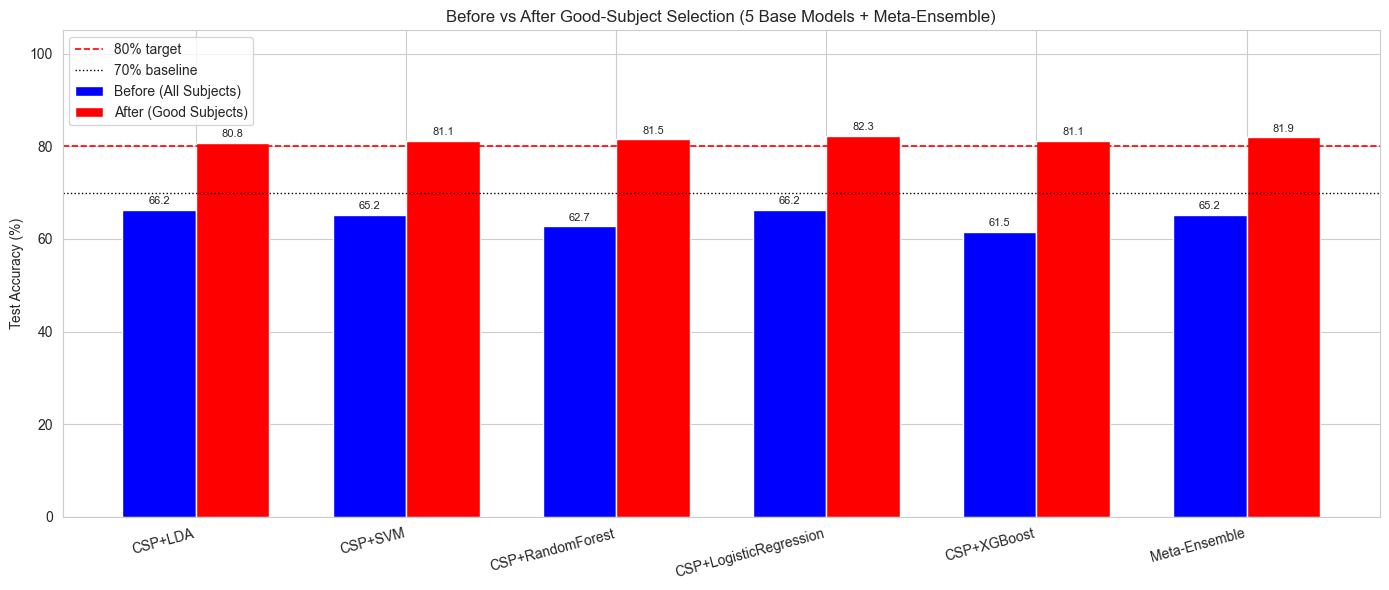

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(before_after_df))
w = 0.35
b1 = ax.bar(x - w/2, before_after_df.iloc[:, 1], w,
            label="Before (All Subjects)", color="blue")
b2 = ax.bar(x + w/2, before_after_df.iloc[:, 2], w,
            label="After (Good Subjects)", color="red")
ax.axhline(80, color="red",   linestyle="--", lw=1.2, label="80% target")
ax.axhline(70, color="black", linestyle=":",  lw=1.0, label="70% baseline")
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8, f"{bar.get_height():.1f}",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(before_after_df["Model"], rotation=15, ha="right")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Before vs After Good-Subject Selection (5 Base Models + Meta-Ensemble)")
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

## 14. Confusion Matrices

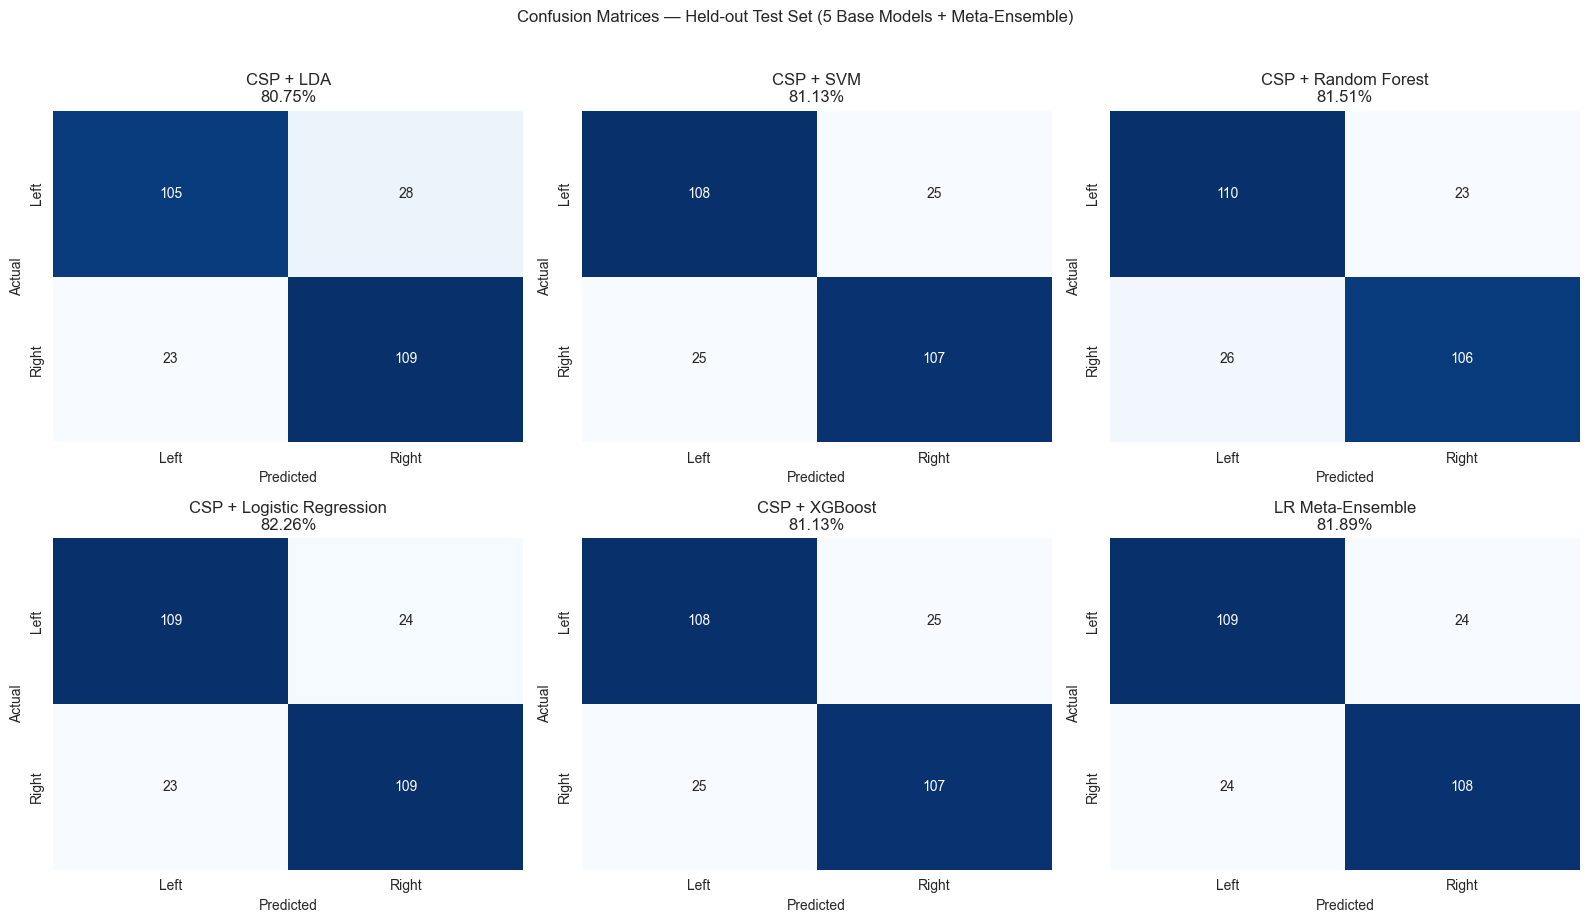

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
model_preds = [
    ("CSP + LDA",                 y_pred_lda),
    ("CSP + SVM",                  y_pred_svm),
    ("CSP + Random Forest",        y_pred_rf),
    ("CSP + Logistic Regression",  y_pred_lr),
    ("CSP + XGBoost",              y_pred_xgb_base),
    ("LR Meta-Ensemble",            y_pred_meta),
]
for ax, (name, yp) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Left","Right"],
                yticklabels=["Left","Right"], ax=ax)
    ax.set_title(f"{name}\n{accuracy_score(y_test, yp)*100:.2f}%")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — Held-out Test Set (5 Base Models + Meta-Ensemble)", y=1.02)
plt.tight_layout()
plt.show()

## 15. Good vs Bad Subject Ratio

**Graph 1** — Pie chart showing how many subjects were accepted vs rejected by the
screening threshold, with the exact count on each slice.


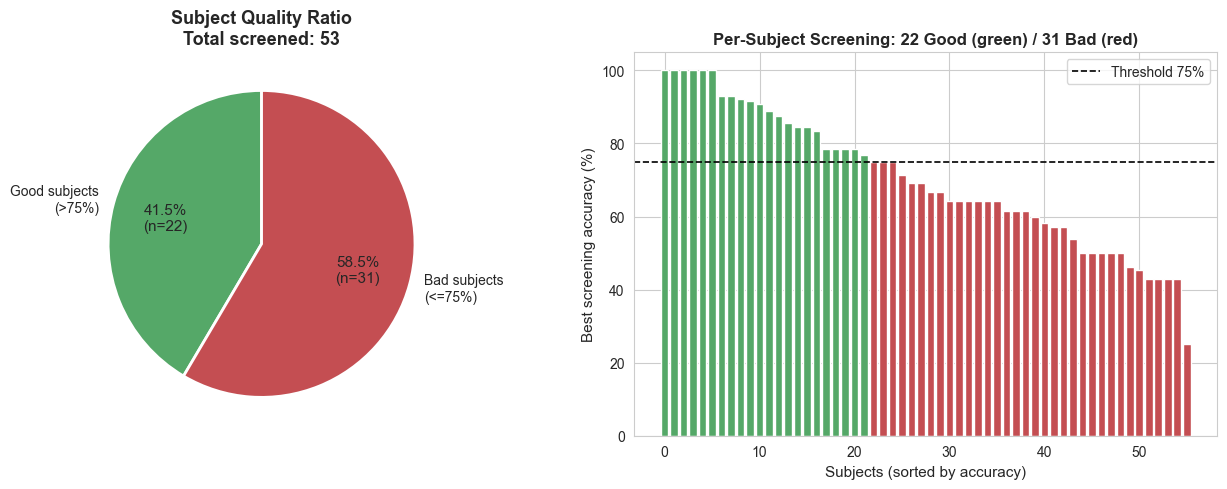

In [27]:
n_good = len(good_subjects)
n_bad  = len(bad_subjects_screened)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: pie chart ────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    [n_good, n_bad],
    labels=[f"Good subjects\n(>{GOOD_SUBJECT_THRESHOLD*100:.0f}%)",
            f"Bad subjects\n(<={GOOD_SUBJECT_THRESHOLD*100:.0f}%)"],
    autopct=lambda p: f"{p:.1f}%\n(n={int(round(p*(n_good+n_bad)/100))})",
    colors=["#55A868", "#C44E52"],
    startangle=90, pctdistance=0.65,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts:
    at.set_fontsize(11)
axes[0].set_title(f"Subject Quality Ratio\nTotal screened: {n_good+n_bad}",
                  fontsize=13, fontweight="bold")

# ── Right: accuracy bar per subject (sorted, coloured) ────────────────────
colors_bar = ["#55A868" if s in good_subjects else "#C44E52"
              for s in screening_df["subject"]]
axes[1].bar(range(len(screening_df)), screening_df["best_acc"]*100, color=colors_bar)
axes[1].axhline(GOOD_SUBJECT_THRESHOLD*100, color="black",
                linestyle="--", lw=1.2, label=f"Threshold {GOOD_SUBJECT_THRESHOLD*100:.0f}%")
axes[1].set_xlabel("Subjects (sorted by accuracy)", fontsize=11)
axes[1].set_ylabel("Best screening accuracy (%)", fontsize=11)
axes[1].set_title(f"Per-Subject Screening: {n_good} Good (green) / {n_bad} Bad (red)",
                  fontsize=12, fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.show()


## 16. Left Hand vs Right Hand Classification Results

Two separate bar charts — one per class — showing how many trials were correctly classified
(true positives) vs misclassified (false negatives) by the XGBoost Meta-Ensemble.


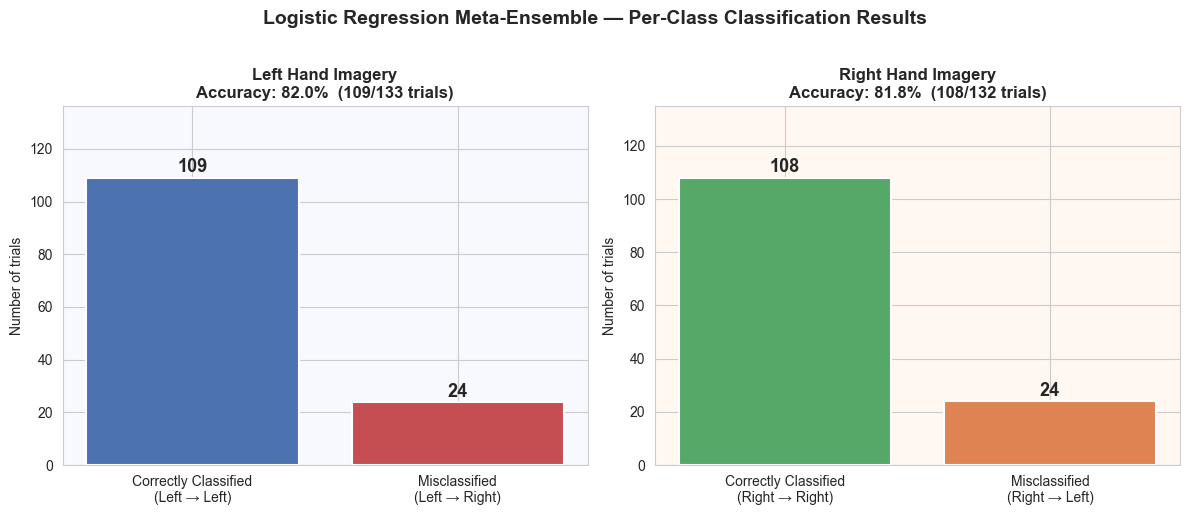

Left  hand:  109 correct  /  24 misclassified  (82.0%)
Right hand:  108 correct  /  24 misclassified  (81.8%)


In [28]:
cm_meta = confusion_matrix(y_test, y_pred_meta)
# cm_meta[0,0] = Left  correctly predicted (TP for Left)
# cm_meta[0,1] = Left  predicted as Right  (FN for Left)
# cm_meta[1,0] = Right predicted as Left   (FN for Right)
# cm_meta[1,1] = Right correctly predicted (TP for Right)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5))

# ── Left Hand chart ────────────────────────────────────────────────────────
left_correct = cm_meta[0, 0]
left_wrong   = cm_meta[0, 1]
bars_l = ax_l.bar(["Correctly Classified\n(Left → Left)",
                    "Misclassified\n(Left → Right)"],
                   [left_correct, left_wrong],
                   color=["#4C72B0", "#C44E52"], edgecolor="white", linewidth=1.5)
for bar in bars_l:
    ax_l.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.5,
              str(int(bar.get_height())), ha="center", va="bottom",
              fontsize=13, fontweight="bold")
total_left = left_correct + left_wrong
ax_l.set_title(
    f"Left Hand Imagery\n"
    f"Accuracy: {left_correct/total_left*100:.1f}%  ({left_correct}/{total_left} trials)",
    fontsize=12, fontweight="bold")
ax_l.set_ylabel("Number of trials")
ax_l.set_ylim(0, max(left_correct, left_wrong) * 1.25)
ax_l.set_facecolor("#F8F8FF")

# ── Right Hand chart ───────────────────────────────────────────────────────
right_correct = cm_meta[1, 1]
right_wrong   = cm_meta[1, 0]
bars_r = ax_r.bar(["Correctly Classified\n(Right → Right)",
                    "Misclassified\n(Right → Left)"],
                   [right_correct, right_wrong],
                   color=["#55A868", "#DD8452"], edgecolor="white", linewidth=1.5)
for bar in bars_r:
    ax_r.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.5,
              str(int(bar.get_height())), ha="center", va="bottom",
              fontsize=13, fontweight="bold")
total_right = right_correct + right_wrong
ax_r.set_title(
    f"Right Hand Imagery\n"
    f"Accuracy: {right_correct/total_right*100:.1f}%  ({right_correct}/{total_right} trials)",
    fontsize=12, fontweight="bold")
ax_r.set_ylabel("Number of trials")
ax_r.set_ylim(0, max(right_correct, right_wrong) * 1.25)
ax_r.set_facecolor("#FFF8F0")

plt.suptitle("Logistic Regression Meta-Ensemble — Per-Class Classification Results",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Left  hand:  {left_correct} correct  /  {left_wrong} misclassified  "
      f"({left_correct/total_left*100:.1f}%)")
print(f"Right hand:  {right_correct} correct  /  {right_wrong} misclassified  "
      f"({right_correct/total_right*100:.1f}%)")

## 17. ROC + AUC Curve

Two evaluations, plotted together for direct comparison:
- **Meta-Ensemble (blue):** the Logistic Regression meta-learner's predicted
  probabilities on the truly held-out test set (`X_meta_test` -> `meta_lr_model`).
- **CV OOF (red):** the out-of-fold probabilities collected during the 10-fold
  cross-validation in Section 11, averaged across all five base learners. This is
  measured on the *training* set (trial-level folds, not held-out subjects — see the
  Section 11 note on why LOSO was removed), so treat it as a training-side sanity
  check rather than a generalization estimate; the blue curve is the honest one.


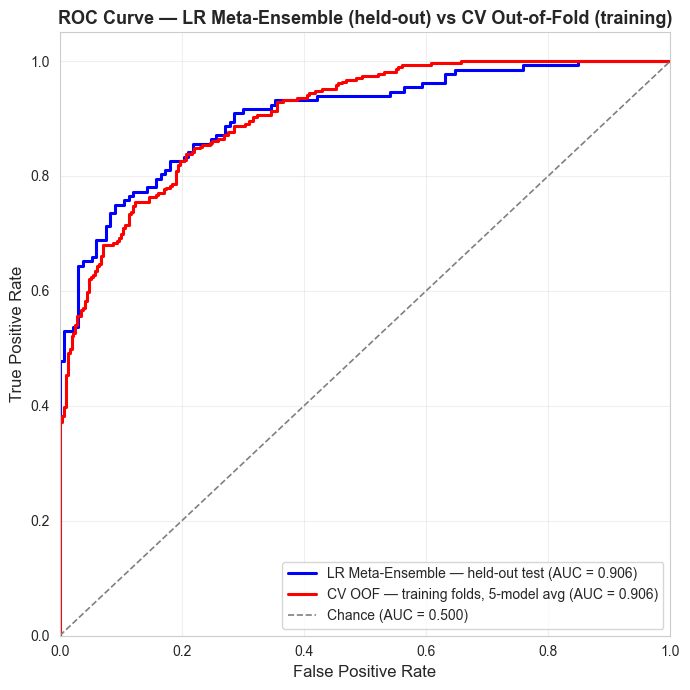

LR Meta-Ensemble (held-out test) AUC : 0.9064
CV OOF (training folds, 5-model avg) AUC : 0.9063


In [29]:
# ── Ensemble (held-out test set) ROC ──────────────────────────────────────
ens_test_prob = np.asarray(meta_lr_model.predict_proba(X_meta_test)[:, 1]).ravel()
fpr_ens, tpr_ens, _ = roc_curve(y_test.astype(int), ens_test_prob)
auc_ens = auc(fpr_ens, tpr_ens)

# ── CV OOF (training-set out-of-fold, 5-model average) ───────────────────────
cv_ens_prob = np.asarray(
    (oof_lda_prob + oof_svm_prob + oof_rf_prob + oof_lr_prob + oof_xgb_prob) / 5.0
).ravel()
fpr_cv, tpr_cv, _ = roc_curve(y_train.astype(int), cv_ens_prob)
auc_cv = auc(fpr_cv, tpr_cv)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr_ens, tpr_ens, color="blue", lw=2.2,
        label=f"LR Meta-Ensemble — held-out test (AUC = {auc_ens:.3f})")
ax.plot(fpr_cv, tpr_cv, color="red", lw=2.2,
        label=f"CV OOF — training folds, 5-model avg (AUC = {auc_cv:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle="--", label="Chance (AUC = 0.500)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — LR Meta-Ensemble (held-out) vs CV Out-of-Fold (training)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"LR Meta-Ensemble (held-out test) AUC : {auc_ens:.4f}")
print(f"CV OOF (training folds, 5-model avg) AUC : {auc_cv:.4f}")


## 17.1 Loss Chart (Meta-Ensemble & CV OOF)

Logistic Regression has no boosting rounds, so there is no per-round training curve
to plot here (that was specific to the old XGBoost meta-learner). Instead this shows
log-loss computed directly on: the meta-training data, the held-out test data, and
the training-side CV out-of-fold predictions — a fair comparison across all three.


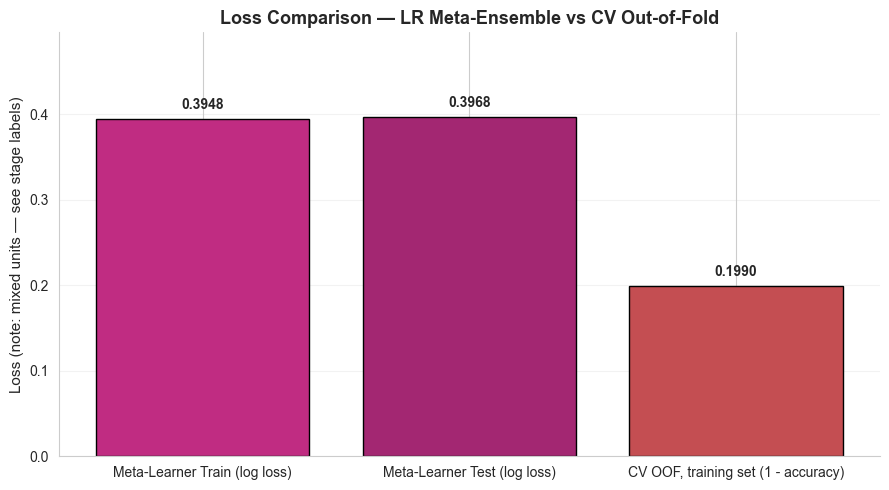

Meta-learner training log loss : 0.3948
Meta-learner test (held-out) log loss : 0.3968
CV OOF loss (1 - accuracy, 5-model average, training set) : 19.90%


In [30]:
# ── Log-loss for the Logistic Regression meta-learner ─────────────────────
meta_train_prob = meta_lr_model.predict_proba(X_meta_train)[:, 1]
meta_test_prob  = meta_lr_model.predict_proba(X_meta_test)[:, 1]

meta_train_loss = log_loss(y_meta_train, meta_train_prob)
meta_test_loss  = log_loss(y_test, meta_test_prob)

# CV OOF loss from the true out-of-fold, 5-model-averaged training-set probabilities
cv_ens_prob = (oof_lda_prob + oof_svm_prob + oof_rf_prob + oof_lr_prob + oof_xgb_prob) / 5.0
cv_preds    = (cv_ens_prob >= 0.5).astype(int)
cv_acc_loss = 1 - accuracy_score(y_train, cv_preds)

loss_df = pd.DataFrame({
    "Stage": ["Meta-Learner Train (log loss)", "Meta-Learner Test (log loss)",
              "CV OOF, training set (1 - accuracy)"],
    "Loss": [meta_train_loss, meta_test_loss, cv_acc_loss],
})
colors = ["#C02C82", "#A32772", "#C44E52"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(loss_df["Stage"], loss_df["Loss"], color=colors, edgecolor="black", linewidth=1.0)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(loss_df["Loss"]) * 0.02,
        f"{height:.4f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, max(loss_df["Loss"]) * 1.25)
ax.set_ylabel("Loss (note: mixed units — see stage labels)", fontsize=11)
ax.set_title("Loss Comparison — LR Meta-Ensemble vs CV Out-of-Fold", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Meta-learner training log loss : {meta_train_loss:.4f}")
print(f"Meta-learner test (held-out) log loss : {meta_test_loss:.4f}")
print(f"CV OOF loss (1 - accuracy, 5-model average, training set) : {cv_acc_loss*100:.2f}%")


## 17.2 Loss curve-Training vs Validation Loss Curve for Ensemble Learning

## 18. Final Summary Table (All Metrics)

In [31]:
summary_data = []
model_list = [
    ("FBCSP+LDA",                  y_pred_lda,       "LDA"),
    ("FBCSP+SVM",                  y_pred_svm,       "SVM"),
    ("FBCSP+RandomForest",         y_pred_rf,        "RF"),
    ("FBCSP+LogisticRegression",   y_pred_lr,        "LR"),
    ("FBCSP+XGBoost",              y_pred_xgb_base,  "XGB"),
    ("LR Meta-Ensemble",           y_pred_meta,      None),
]
for mname, yp, cv_key in model_list:
    p, r, f, _ = precision_recall_fscore_support(
        y_test, yp, labels=[0, 1], average="macro", zero_division=0)
    if cv_key is not None:
        cv_acc = round(cv_df.loc[cv_df["Model"] == cv_key, "CV_Accuracy"].values[0] * 100, 2)
    else:
        cv_acc = "-"   # no single-model CV accuracy for a stacked meta-learner
    summary_data.append({
        "Model":          mname,
        "Test Acc (%)":   round(accuracy_score(y_test, yp)*100, 2),
        "Precision (%)":  round(p*100, 2),
        "Recall (%)":     round(r*100, 2),
        "F1 (%)":         round(f*100, 2),
        "CV Acc, train folds (%)": cv_acc,
    })
display(pd.DataFrame(summary_data))


,Model,Test Acc (%),Precision (%),Recall (%),F1 (%),"CV Acc, train folds (%)"
0,FBCSP+LDA,80.75,80.80,80.76,80.75,80.1
1,FBCSP+SVM,81.13,81.13,81.13,81.13,77.68
2,FBCSP+RandomForest,81.51,81.53,81.50,81.51,79.28
3,FBCSP+LogisticRegression,82.26,82.27,82.27,82.26,81.54
4,FBCSP+XGBoost,81.13,81.13,81.13,81.13,80.42
5,LR Meta-Ensemble,81.89,81.89,81.89,81.89,-


## 19. Top-Performing Subjects

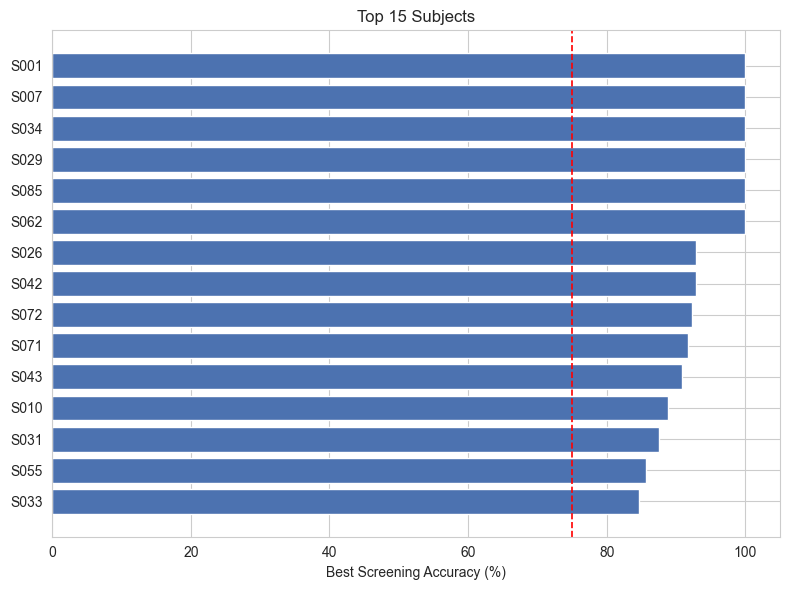

,subject,n_trials,CSP_LDA_acc,CSP_SVM_acc,best_acc
0,S001,30,100.00,77.78,100.00
1,S007,41,100.00,100.00,100.00
2,S034,43,100.00,100.00,100.00
3,S029,40,100.00,91.67,100.00
4,S085,37,91.67,100.00,100.00
5,S062,43,100.00,92.31,100.00
6,S026,45,85.71,92.86,92.86
7,S042,45,85.71,92.86,92.86
8,S072,43,92.31,92.31,92.31
9,S071,37,91.67,91.67,91.67


In [32]:
top_n = min(15, len(screening_df))
fig, ax = plt.subplots(figsize=(8, 6))
top_df = screening_df.head(top_n)
ax.barh(top_df["subject"][::-1], top_df["best_acc"][::-1]*100, color="#4C72B0")
ax.axvline(GOOD_SUBJECT_THRESHOLD*100, color="red", linestyle="--", lw=1.2)
ax.set_xlabel("Best Screening Accuracy (%)")
ax.set_title(f"Top {top_n} Subjects")
plt.tight_layout()
plt.show()
display(top_df[["subject","n_trials","CSP_LDA_acc","CSP_SVM_acc","best_acc"]]
          .assign(**{c: lambda df, c=c: (df[c]*100).round(2)
                     for c in ["CSP_LDA_acc","CSP_SVM_acc","best_acc"]}))


## 20. Save Results & Models

In [33]:
# import joblib
# OUTPUT_DIR = os.path.join(BASE_DIR, "..", "trained_models_v9")
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# screening_df.to_csv(os.path.join(OUTPUT_DIR, "per_subject_screening.csv"), index=False)
# before_after_df.to_csv(os.path.join(OUTPUT_DIR, "before_after_comparison.csv"), index=False)

# joblib.dump(fbcsp_lda,      os.path.join(OUTPUT_DIR, "fbcsp_lda.pkl"))
# joblib.dump(fbcsp_svm,      os.path.join(OUTPUT_DIR, "fbcsp_svm.pkl"))
# joblib.dump(fbcsp_rf,       os.path.join(OUTPUT_DIR, "fbcsp_rf.pkl"))
# joblib.dump(fbcsp_lr,       os.path.join(OUTPUT_DIR, "fbcsp_lr.pkl"))
# joblib.dump(fbcsp_xgb,      os.path.join(OUTPUT_DIR, "fbcsp_xgb.pkl"))
# joblib.dump(lda_model,      os.path.join(OUTPUT_DIR, "lda_model.pkl"))
# joblib.dump(svm_model,      os.path.join(OUTPUT_DIR, "svm_model.pkl"))
# joblib.dump(rf_model,       os.path.join(OUTPUT_DIR, "rf_model.pkl"))
# joblib.dump(lr_model,       os.path.join(OUTPUT_DIR, "lr_model.pkl"))
# joblib.dump(xgb_base_model, os.path.join(OUTPUT_DIR, "xgb_base_model.pkl"))
# joblib.dump(meta_lr_model,  os.path.join(OUTPUT_DIR, "lr_meta_ensemble.pkl"))
# joblib.dump(good_subjects,  os.path.join(OUTPUT_DIR, "good_subjects.pkl"))
# print(f"Saved to: {os.path.abspath(OUTPUT_DIR)}")


## 21. EEGNet Architecture of CNN (Proper Description)

**EEGNet** (Lawhern et al., 2018) is a compact convolutional neural network purpose-
built for EEG-based brain-computer interfaces. Unlike CSP, which is a hand-engineered
spatial filter computed *separately* from the classifier, EEGNet learns both the
spatial and temporal filters directly from raw multi-channel EEG epochs, end-to-end.

**Input:** a single trial as a 2-D array of shape `(Channels, Time)` — here the 13
motor channels x ~480 samples (the 0.5-3.5 s imagery window at 160 Hz), the exact same
preprocessed epochs used by the CSP + LDA/SVM/AdaBoost ensemble.

**Block 1 - Temporal Convolution.** A `Conv2D` layer with `F1` filters of kernel size
`(1, kernLength)` slides only along the time axis, learning band-pass-like temporal
filters (conceptually similar to the mu/beta filtering already applied during
preprocessing, but learned rather than fixed). Followed by BatchNormalization.

**Block 1 - Depthwise Spatial Convolution.** A `DepthwiseConv2D` layer with kernel
`(Chans, 1)` and depth multiplier `D` learns `D` spatial filters per temporal filter -
this is EEGNet's direct analogue of CSP: it learns how to weight and combine the
electrodes for each temporal filter, projecting the channel dimension down onto
sensorimotor-relevant spatial patterns. ELU activation, average pooling `(1,4)`, and
Dropout follow to reduce the time dimension and regularize.

**Block 2 - Separable Convolution.** A `SeparableConv2D` layer (a depthwise
convolution across time, followed by a pointwise convolution across feature maps)
learns how to optimally combine Block 1's feature maps into `F2` summary features,
again followed by ELU, average pooling `(1,8)`, and Dropout.

**Classification Head.** The pooled feature maps are flattened and passed through a
`Dense` layer with `softmax` activation, producing Left-hand / Right-hand class
probabilities.

**Why it fits this project:** EEGNet is trained on the *same* ICA-cleaned, band-passed,
epoched trials (`X_train` / `X_test` from Section 10) that feed the CSP + LDA/SVM/
AdaBoost ensemble — no CSP dimensionality reduction is applied here, since EEGNet's
depthwise convolution learns its own spatial filter directly from the 13-channel
signal. This gives a fair, apples-to-apples comparison between a hand-engineered
pipeline (CSP + classical ML) and an end-to-end deep-learning pipeline, on identical
data and an identical train/test split.

*Requires TensorFlow (`pip install tensorflow`).*

In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)

# Reuse the EXACT same preprocessed epochs and train/test split as the ensemble
# (Section 10) — X_train / X_test are pre-CSP, ICA-cleaned, band-passed trials.
Chans, Samples = X_train.shape[1], X_train.shape[2]
print(f"EEGNet input shape per trial: ({Chans} channels, {Samples} samples)")

X_train_eeg = X_train[..., np.newaxis].astype("float32")   # (n_trials, Chans, Samples, 1)
X_test_eeg  = X_test[...,  np.newaxis].astype("float32")

y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat  = to_categorical(y_test,  num_classes=2)

print(f"X_train_eeg: {X_train_eeg.shape}   X_test_eeg: {X_test_eeg.shape}")
print(f"y_train_cat: {y_train_cat.shape}   y_test_cat: {y_test_cat.shape}")

EEGNet input shape per trial: (13 channels, 561 samples)
X_train_eeg: (618, 13, 561, 1)   X_test_eeg: (265, 13, 561, 1)
y_train_cat: (618, 2)   y_test_cat: (265, 2)


### 21.1 Build & Train EEGNet

In [45]:
def EEGNet(nb_classes, Chans, Samples, dropoutRate=0.5, kernLength=64,
           F1=8, D=2, F2=16, norm_rate=0.25):
    """
    Compact CNN for EEG motor-imagery classification (Lawhern et al., 2018).
    Input : (Chans, Samples, 1)
    Output: softmax over `nb_classes`
    """
    input1 = layers.Input(shape=(Chans, Samples, 1))

    # Block 1 - Temporal convolution (learned band-pass-like filters)
    block1 = layers.Conv2D(F1, (1, kernLength), padding="same", use_bias=False)(input1)
    block1 = layers.BatchNormalization()(block1)

    # Block 1 - Depthwise spatial convolution (EEGNet's CSP-like spatial filter)
    block1 = layers.DepthwiseConv2D(
        (Chans, 1), use_bias=False, depth_multiplier=D,
        depthwise_constraint=tf.keras.constraints.max_norm(1.))(block1)
    block1 = layers.BatchNormalization()(block1)
    block1 = layers.Activation("elu")(block1)
    block1 = layers.AveragePooling2D((1, 4))(block1)
    block1 = layers.Dropout(dropoutRate)(block1)

    # Block 2 - Separable convolution (temporal summary + feature mixing)
    block2 = layers.SeparableConv2D(F2, (1, 16), use_bias=False, padding="same")(block1)
    block2 = layers.BatchNormalization()(block2)
    block2 = layers.Activation("elu")(block2)
    block2 = layers.AveragePooling2D((1, 8))(block2)
    block2 = layers.Dropout(dropoutRate)(block2)

    flatten = layers.Flatten()(block2)
    dense = layers.Dense(nb_classes,
                          kernel_constraint=tf.keras.constraints.max_norm(norm_rate))(flatten)
    softmax = layers.Activation("softmax")(dense)

    return models.Model(inputs=input1, outputs=softmax, name="EEGNet")


eegnet_model = EEGNet(nb_classes=2, Chans=Chans, Samples=Samples)
eegnet_model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)
eegnet_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = eegnet_model.fit(
    X_train_eeg, y_train_cat,
    validation_data=(X_test_eeg, y_test_cat),
    batch_size=16,
    epochs=150,
    callbacks=[early_stop],
    verbose=2,
)

Model: "EEGNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 13, 561, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 561, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 13, 561, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 561, 16)     │           208 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1, 561, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 1, 561, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 140, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 140, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 140, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1, 140, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 1, 140, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 17, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 17, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 272)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           546 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,938 (7.57 KB)

 Trainable params: 1,858 (7.26 KB)

 Non-trainable params: 80 (320.00 B)

Epoch 1/150
39/39 - 7s - 182ms/step - accuracy: 0.4806 - loss: 0.6962 - val_accuracy: 0.5094 - val_loss: 0.6931
Epoch 2/150
39/39 - 2s - 45ms/step - accuracy: 0.5728 - loss: 0.6832 - val_accuracy: 0.5132 - val_loss: 0.6930
Epoch 3/150
39/39 - 2s - 61ms/step - accuracy: 0.5502 - loss: 0.6802 - val_accuracy: 0.5434 - val_loss: 0.6900
Epoch 4/150
39/39 - 3s - 71ms/step - accuracy: 0.6262 - loss: 0.6580 - val_accuracy: 0.5887 - val_loss: 0.6727
Epoch 5/150
39/39 - 4s - 111ms/step - accuracy: 0.6650 - loss: 0.6272 - val_accuracy: 0.6302 - val_loss: 0.6153
Epoch 6/150
39/39 - 2s - 46ms/step - accuracy: 0.7087 - loss: 0.5629 - val_accuracy: 0.6302 - val_loss: 0.5727
Epoch 7/150
39/39 - 2s - 56ms/step - accuracy: 0.7120 - loss: 0.5231 - val_accuracy: 0.7509 - val_loss: 0.4858
Epoch 8/150
39/39 - 2s - 47ms/step - accuracy: 0.7395 - loss: 0.4896 - val_accuracy: 0.7660 - val_loss: 0.4569
Epoch 9/150
39/39 - 2s - 51ms/step - accuracy: 0.7735 - loss: 0.4684 - val_accuracy: 0.7736 - val_loss: 0.4440

### 21.2 EEGNet — Confusion Matrix, Precision, Recall, F1, Support

EEGNet Test Accuracy: 83.02%

Per-class metrics (Left=0, Right=1):
  Left: precision=0.8188  recall=0.8496  f1=0.8339  support=133
  Right: precision=0.8425  recall=0.8106  f1=0.8263  support=132

Classification Report:
              precision    recall  f1-score   support

        Left     0.8188    0.8496    0.8339       133
       Right     0.8425    0.8106    0.8263       132

    accuracy                         0.8302       265
   macro avg     0.8307    0.8301    0.8301       265
weighted avg     0.8306    0.8302    0.8301       265



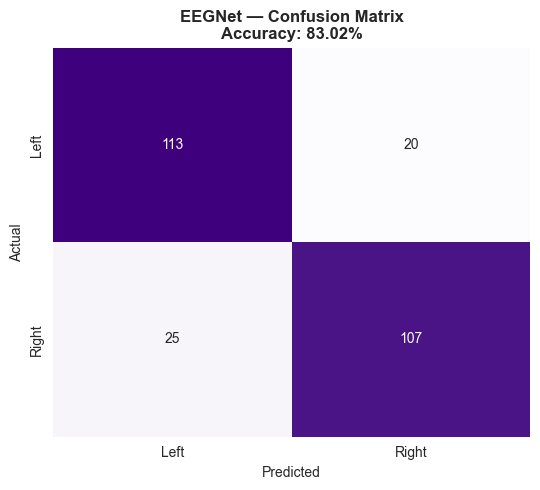

,Class,Precision,Recall,F1-score,Support
0,Left,0.8188,0.8496,0.8339,133
1,Right,0.8425,0.8106,0.8263,132


In [46]:
eegnet_test_probs = eegnet_model.predict(X_test_eeg, verbose=0)
eegnet_test_prob  = eegnet_test_probs[:, 1]
y_pred_eegnet     = np.argmax(eegnet_test_probs, axis=1)
acc_eegnet        = accuracy_score(y_test, y_pred_eegnet)

prec_eegnet, rec_eegnet, f1_eegnet, sup_eegnet = precision_recall_fscore_support(
    y_test, y_pred_eegnet, labels=[0, 1])

print(f"EEGNet Test Accuracy: {acc_eegnet*100:.2f}%\n")
print("Per-class metrics (Left=0, Right=1):")
for i, name in enumerate(["Left", "Right"]):
    print(f"  {name}: precision={prec_eegnet[i]:.4f}  recall={rec_eegnet[i]:.4f}"
          f"  f1={f1_eegnet[i]:.4f}  support={sup_eegnet[i]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_eegnet, target_names=["Left", "Right"], digits=4))

cm_eegnet = confusion_matrix(y_test, y_pred_eegnet)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm_eegnet, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["Left", "Right"], yticklabels=["Left", "Right"], ax=ax)
ax.set_title(f"EEGNet — Confusion Matrix\nAccuracy: {acc_eegnet*100:.2f}%",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

eegnet_metrics_df = pd.DataFrame({
    "Class":     ["Left", "Right"],
    "Precision": np.round(prec_eegnet, 4),
    "Recall":    np.round(rec_eegnet, 4),
    "F1-score":  np.round(f1_eegnet, 4),
    "Support":   sup_eegnet,
})
display(eegnet_metrics_df)

### 21.3 EEGNet — ROC & AUC Curve

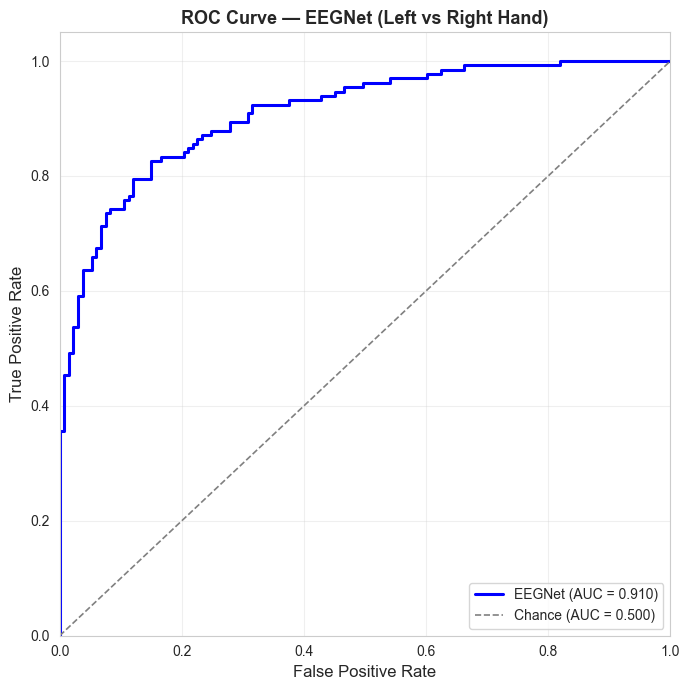

EEGNet Test AUC: 0.9102


In [47]:
fpr_eegnet, tpr_eegnet, _ = roc_curve(y_test, eegnet_test_prob)
auc_eegnet = auc(fpr_eegnet, tpr_eegnet)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr_eegnet, tpr_eegnet, color="blue", lw=2.2, label=f"EEGNet (AUC = {auc_eegnet:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle="--", label="Chance (AUC = 0.500)")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — EEGNet (Left vs Right Hand)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"EEGNet Test AUC: {auc_eegnet:.4f}")

### 21.4 EEGNet — Training vs Validation Loss Curve

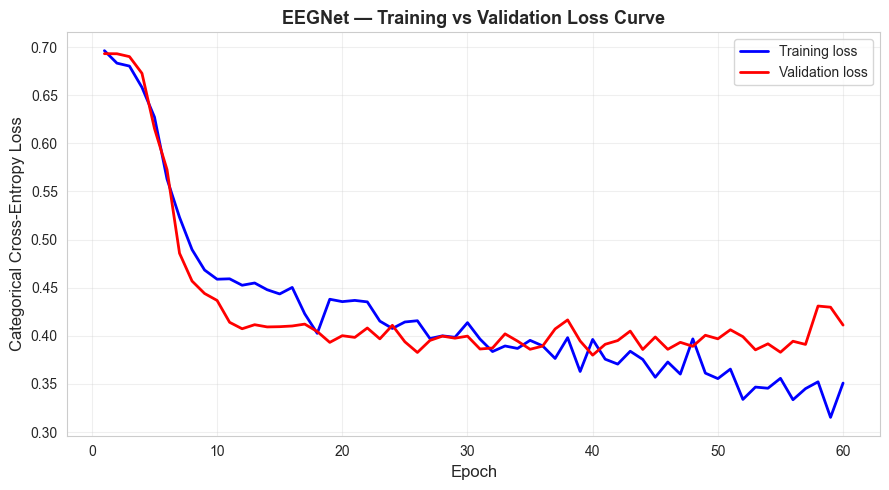

Final training loss   (epoch 60): 0.3510
Final validation loss (epoch 60): 0.4112
Training loss   change: 0.6962 → 0.3510
Validation loss change: 0.6931 → 0.4112

✓ EEGNet reached the 80% target: 83.02%


In [48]:
train_loss_hist = history.history["loss"]
val_loss_hist   = history.history["val_loss"]
n_epochs_ran    = len(train_loss_hist)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, n_epochs_ran + 1), train_loss_hist, color="blue", lw=2, label="Training loss")
ax.plot(range(1, n_epochs_ran + 1), val_loss_hist, color="red", lw=2, label="Validation loss")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Categorical Cross-Entropy Loss", fontsize=12)
ax.set_title("EEGNet — Training vs Validation Loss Curve", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_train_loss_eegnet = train_loss_hist[-1]
final_val_loss_eegnet   = val_loss_hist[-1]
print(f"Final training loss   (epoch {n_epochs_ran}): {final_train_loss_eegnet:.4f}")
print(f"Final validation loss (epoch {n_epochs_ran}): {final_val_loss_eegnet:.4f}")
print(f"Training loss   change: {train_loss_hist[0]:.4f} → {final_train_loss_eegnet:.4f}")
print(f"Validation loss change: {val_loss_hist[0]:.4f} → {final_val_loss_eegnet:.4f}")

TARGET = 0.80
if acc_eegnet >= TARGET:
    print(f"\n✓ EEGNet reached the {TARGET*100:.0f}% target: {acc_eegnet*100:.2f}%")
else:
    print(f"\n✗ EEGNet at {acc_eegnet*100:.2f}% — below the {TARGET*100:.0f}% target.")
    print("  Try: more epochs/patience, tune F1/D/F2/kernLength, or more training subjects.")

## 25. DeepConvNet — Deep Convolutional Network for EEG Motor Imagery

In [49]:
# DeepConvNet section — same preprocessing and evaluation style as EEGNet
# Reuse the same preprocessed EEG data and split logic as the existing EEGNet section.

In [50]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(RANDOM_STATE)

def create_deepconvnet(n_channels=13, n_times=480, n_classes=2):
    """
    DeepConvNet architecture inspired by Schirrmeister et al. (2017).
    Input shape is expected to be (None, 1, n_channels, n_times).
    """
    input1 = layers.Input(shape=(1, n_channels, n_times), name="input")

    # Block 1
    x = layers.Conv2D(25, (1, 5), padding="same",
                      data_format="channels_first", use_bias=False)(input1)
    x = layers.BatchNormalization(axis=1)(x)
    x = layers.Activation("elu")(x)
    x = layers.Conv2D(25, (n_channels, 1), padding="valid",
                      data_format="channels_first", use_bias=False)(x)
    x = layers.BatchNormalization(axis=1)(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling2D(pool_size=(1, 2), data_format="channels_first")(x)
    x = layers.Dropout(0.5)(x)

    # Block 2
    x = layers.Conv2D(50, (1, 5), padding="same",
                      data_format="channels_first", use_bias=False)(x)
    x = layers.BatchNormalization(axis=1)(x)
    x = layers.Activation("elu")(x)
    x = layers.Conv2D(50, (1, 5), padding="same",
                      data_format="channels_first", use_bias=False)(x)
    x = layers.BatchNormalization(axis=1)(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling2D(pool_size=(1, 2), data_format="channels_first")(x)
    x = layers.Dropout(0.5)(x)

    # Block 3
    x = layers.Conv2D(100, (1, 5), padding="same",
                      data_format="channels_first", use_bias=False)(x)
    x = layers.BatchNormalization(axis=1)(x)
    x = layers.Activation("elu")(x)
    x = layers.Conv2D(100, (1, 5), padding="same",
                      data_format="channels_first", use_bias=False)(x)
    x = layers.BatchNormalization(axis=1)(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling2D(pool_size=(1, 2), data_format="channels_first")(x)
    x = layers.Dropout(0.5)(x)

    # Block 4
    x = layers.Conv2D(200, (1, 5), padding="same",
                      data_format="channels_first", use_bias=False)(x)
    x = layers.BatchNormalization(axis=1)(x)
    x = layers.Activation("elu")(x)
    x = layers.Conv2D(200, (1, 5), padding="same",
                      data_format="channels_first", use_bias=False)(x)
    x = layers.BatchNormalization(axis=1)(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling2D(pool_size=(1, 2), data_format="channels_first")(x)
    x = layers.Dropout(0.5)(x)

    # Classification head
    x = layers.Flatten()(x)
    x = layers.Dense(200, activation="elu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(n_classes, activation="softmax")(x)

    return models.Model(inputs=input1, outputs=output, name="DeepConvNet")


print("DeepConvNet architecture defined successfully.")

DeepConvNet architecture defined successfully.


## 25.2 Data Preparation & Train/Test Split for DeepConvNet

In [51]:
# Use the same preprocessed EEG trials that were used for EEGNet:
# X_good and y_good are the pooled good-subject trials after preprocessing.
# We perform the same 70/30 stratified split with random_state=42.

n_channels = X_good.shape[1]
n_times = X_good.shape[2]

X_train_deep_raw, X_test_deep_raw, y_train_deep, y_test_deep = train_test_split(
    X_good, y_good, test_size=0.30, random_state=RANDOM_STATE, stratify=y_good)

# Reshape to (n_trials, 1, n_channels, n_times) for DeepConvNet
X_train_deep = X_train_deep_raw[:, np.newaxis, :, :].astype("float32")
X_test_deep  = X_test_deep_raw[:, np.newaxis, :, :].astype("float32")

# Convert labels to categorical (one-hot)
y_train_cat_deep = to_categorical(y_train_deep, num_classes=2)
y_test_cat_deep  = to_categorical(y_test_deep, num_classes=2)

print(f"DeepConvNet input shape per trial: ({n_channels} channels, {n_times} samples)")
print(f"X_train_deep: {X_train_deep.shape}   X_test_deep: {X_test_deep.shape}")
print(f"y_train_cat_deep: {y_train_cat_deep.shape}   y_test_cat_deep: {y_test_cat_deep.shape}")

DeepConvNet input shape per trial: (13 channels, 561 samples)
X_train_deep: (618, 1, 13, 561)   X_test_deep: (265, 1, 13, 561)
y_train_cat_deep: (618, 2)   y_test_cat_deep: (265, 2)


## 25.3 Train DeepConvNet + Evaluate Performance

Model: "DeepConvNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1, 13, 561)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 25, 13, 561)    │           125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 25, 13, 561)    │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 25, 13, 561)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 1, 561)     │         8,125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 1, 561)     │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 25, 1, 561)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 1, 280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 1, 280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 1, 280)     │         6,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 1, 280)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 50, 1, 280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 1, 280)     │        12,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 1, 280)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 50, 1, 280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 1, 140)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 1, 140)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 1, 140)    │        25,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100, 1, 140)    │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100, 1, 140)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 1, 140)    │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 1, 140)    │           400 │
│ (BatchNormalization)            │                        │             

 Total params: 1,805,602 (6.89 MB)

 Trainable params: 1,804,102 (6.88 MB)

 Non-trainable params: 1,500 (5.86 KB)

Epoch 1/150
39/39 - 19s - 478ms/step - accuracy: 0.5032 - loss: 3.2365 - val_accuracy: 0.5736 - val_loss: 0.6713 - learning_rate: 0.0010
Epoch 2/150
39/39 - 8s - 212ms/step - accuracy: 0.5502 - loss: 1.0167 - val_accuracy: 0.6377 - val_loss: 0.6351 - learning_rate: 0.0010
Epoch 3/150
39/39 - 10s - 264ms/step - accuracy: 0.4935 - loss: 1.0036 - val_accuracy: 0.6453 - val_loss: 0.5998 - learning_rate: 0.0010
Epoch 4/150
39/39 - 11s - 285ms/step - accuracy: 0.6149 - loss: 0.8679 - val_accuracy: 0.7509 - val_loss: 0.4727 - learning_rate: 0.0010
Epoch 5/150
39/39 - 9s - 239ms/step - accuracy: 0.6683 - loss: 0.7449 - val_accuracy: 0.7509 - val_loss: 0.5102 - learning_rate: 0.0010
Epoch 6/150
39/39 - 8s - 199ms/step - accuracy: 0.7346 - loss: 0.6572 - val_accuracy: 0.7736 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 7/150
39/39 - 7s - 189ms/step - accuracy: 0.7346 - loss: 0.6334 - val_accuracy: 0.7509 - val_loss: 0.4769 - learning_rate: 0.0010
Epoch 8/150
39/39 - 7s - 189ms/step - accurac

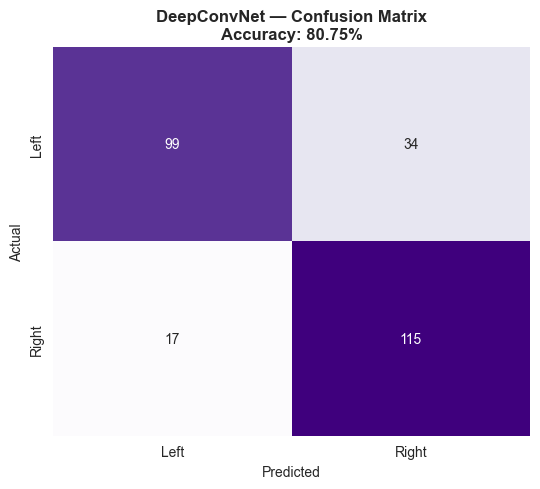

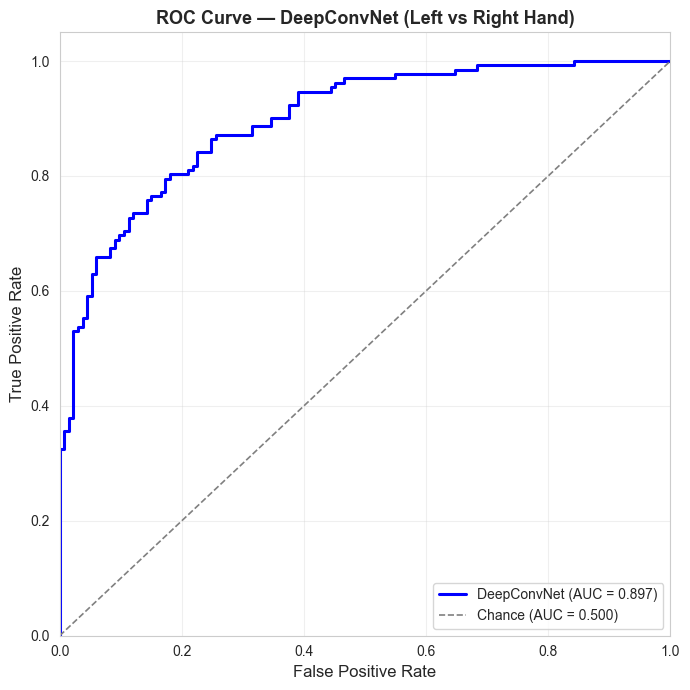

DeepConvNet Test AUC: 0.8968


In [52]:
# Clear previous model state and build the DeepConvNet
tf.keras.backend.clear_session()

deepconvnet_model = create_deepconvnet(
    n_channels=n_channels,
    n_times=n_times,
    n_classes=2
)

deepconvnet_model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

deepconvnet_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6)

history_deep = deepconvnet_model.fit(
    X_train_deep, y_train_cat_deep,
    validation_data=(X_test_deep, y_test_cat_deep),
    batch_size=16,
    epochs=150,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)

# Predict on the test set
deepconvnet_test_probs = deepconvnet_model.predict(X_test_deep, verbose=0)
deepconvnet_test_prob  = deepconvnet_test_probs[:, 1]
y_pred_deep           = np.argmax(deepconvnet_test_probs, axis=1)

# Accuracy
acc_deepconvnet = accuracy_score(y_test_deep, y_pred_deep)

# Classification Report
prec_deepconvnet, rec_deepconvnet, f1_deepconvnet, sup_deepconvnet = precision_recall_fscore_support(
    y_test_deep, y_pred_deep, labels=[0, 1])

print(f"DeepConvNet Test Accuracy: {acc_deepconvnet*100:.2f}%\n")
print("Per-class metrics (Left=0, Right=1):")
for i, name in enumerate(["Left", "Right"]):
    print(f"  {name}: precision={prec_deepconvnet[i]:.4f}  recall={rec_deepconvnet[i]:.4f}"
          f"  f1={f1_deepconvnet[i]:.4f}  support={sup_deepconvnet[i]}")
print("\nClassification Report:")
print(classification_report(y_test_deep, y_pred_deep,
                             target_names=["Left", "Right"], digits=4))

# Confusion Matrix
cm_deepconvnet = confusion_matrix(y_test_deep, y_pred_deep)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm_deepconvnet, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["Left", "Right"], yticklabels=["Left", "Right"], ax=ax)
ax.set_title(f"DeepConvNet — Confusion Matrix\nAccuracy: {acc_deepconvnet*100:.2f}%",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC + AUC
fpr_deepconvnet, tpr_deepconvnet, _ = roc_curve(y_test_deep, deepconvnet_test_prob)
auc_deepconvnet = auc(fpr_deepconvnet, tpr_deepconvnet)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr_deepconvnet, tpr_deepconvnet, color="blue", lw=2.2,
        label=f"DeepConvNet (AUC = {auc_deepconvnet:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle="--", label="Chance (AUC = 0.500)")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — DeepConvNet (Left vs Right Hand)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"DeepConvNet Test AUC: {auc_deepconvnet:.4f}")

## 25.4 DeepConvNet Training vs Validation Loss Curve

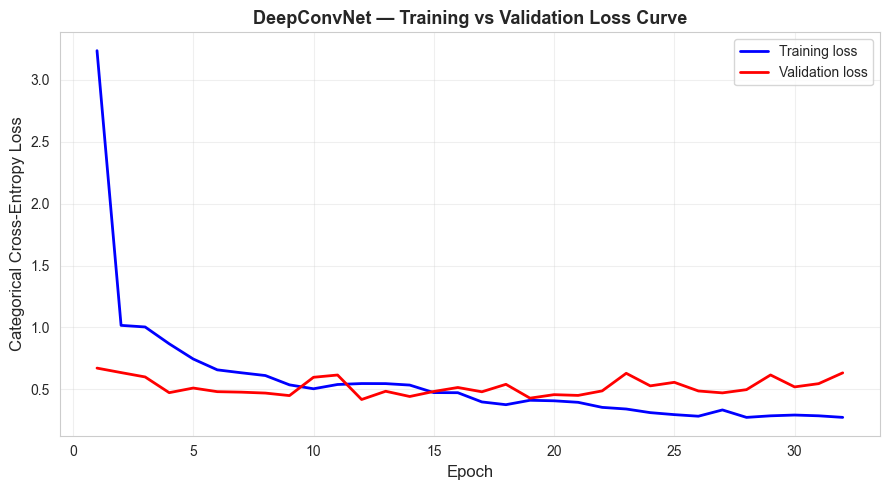

Final training loss   (epoch 32): 0.2732
Final validation loss (epoch 32): 0.6329
Training loss   change: 3.2365 → 0.2732
Validation loss change: 0.6713 → 0.6329

✓ DeepConvNet reached the 80% target: 80.75%
  Compared with EEGNet (83.02%), DeepConvNet achieved 80.75% on the same split and preprocessing.


In [53]:
train_loss_hist_deep = history_deep.history["loss"]
val_loss_hist_deep   = history_deep.history["val_loss"]
n_epochs_ran_deep    = len(train_loss_hist_deep)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, n_epochs_ran_deep + 1), train_loss_hist_deep, color="blue", lw=2,
        label="Training loss")
ax.plot(range(1, n_epochs_ran_deep + 1), val_loss_hist_deep, color="red", lw=2,
        label="Validation loss")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Categorical Cross-Entropy Loss", fontsize=12)
ax.set_title("DeepConvNet — Training vs Validation Loss Curve", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_train_loss_deep = train_loss_hist_deep[-1]
final_val_loss_deep   = val_loss_hist_deep[-1]
print(f"Final training loss   (epoch {n_epochs_ran_deep}): {final_train_loss_deep:.4f}")
print(f"Final validation loss (epoch {n_epochs_ran_deep}): {final_val_loss_deep:.4f}")
print(f"Training loss   change: {train_loss_hist_deep[0]:.4f} → {final_train_loss_deep:.4f}")
print(f"Validation loss change: {val_loss_hist_deep[0]:.4f} → {final_val_loss_deep:.4f}")

TARGET = 0.80
if acc_deepconvnet >= TARGET:
    print(f"\n✓ DeepConvNet reached the {TARGET*100:.0f}% target: {acc_deepconvnet*100:.2f}%")
else:
    print(f"\n✗ DeepConvNet at {acc_deepconvnet*100:.2f}% — below the {TARGET*100:.0f}% target.")
    print("  Try: more epochs/patience, tune the architecture, or use more training subjects.")

# Short comparison with EEGNet
if "acc_eegnet" in globals():
    print(f"  Compared with EEGNet ({acc_eegnet*100:.2f}%), DeepConvNet achieved {acc_deepconvnet*100:.2f}% on the same split and preprocessing.")
else:
    print("  Compared with EEGNet, DeepConvNet is being evaluated under the same data split and preprocessing pipeline.")

## The END